# Final Project 1: Integer Programming for Maximum Independent Set

This notebook is the computational record for the project. It contains the graph generators, greedy baselines, IP formulation, SNAP loader, plotting routines, validation checks, and resumable long-batch runner. It does **not** import local helper modules such as `mis_tools.py` or `run_experiments.py`.

The core question is whether an IP solver can find and/or certify independent sets in $G(n,d/n)$ beyond the greedy scale $(\log d/d)n$, and how the same method behaves on a real SNAP network.

In [1]:
from __future__ import annotations

import csv
import gzip
import heapq
import json
import math
import os
import platform
import random
import re
import subprocess
import tempfile
import time
import urllib.request
from collections import Counter, deque
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pulp
from IPython.display import Image, display

PROJECT_DIR = Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results"
DATA_DIR = PROJECT_DIR / "data"
LONG_BATCH_DIR = RESULTS_DIR / "long_batch"
FINAL_REPORT_RESULTS_DIR = PROJECT_DIR / "69fe50e434542be064946a62" / "results"
SNAP_URL = "https://snap.stanford.edu/data/ca-GrQc.txt.gz"

RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
LONG_BATCH_DIR.mkdir(exist_ok=True)

print(f"Project directory: {PROJECT_DIR.name}")
print(f"PuLP version: {pulp.__version__}")
print(f"Available PuLP solvers: {pulp.listSolvers(onlyAvailable=True)}")

Project directory: final_project_1
PuLP version: 3.3.0
Available PuLP solvers: ['PULP_CBC_CMD']


## Theory Benchmarks

The project prompt compares two asymptotic scales for $G(n,d/n)$:

$$
\text{greedy scale}\approx \frac{\log d}{d}n,
$$

and

$$
\alpha(G(n,d/n))\approx \frac{2\log d}{d}n
$$

in the double asymptotic regime $n\to\infty$ followed by $d\to\infty$.

For finite $d$, the first-moment calculation gives a sharper upper reference.  The expected number of independent sets of size $an$ is approximately

$$
\binom{n}{an}(1-d/n)^{\binom{an}{2}}
\approx
\exp\left(n\left[H(a)-\frac{d a^2}{2}\right]\right),
$$

where $H(a)=-a\log a-(1-a)\log(1-a)$.  The largest positive root of

$$
H(a)-\frac{d a^2}{2}=0
$$

is the finite-$d$ first-moment benchmark.  For $d=20$, this is about $0.233$, substantially below $2\log(20)/20\approx 0.300$.

## Graph Representation and Basic Utilities

In [2]:
Adjacency = List[Set[int]]
Edge = Tuple[int, int]


def empty_graph(n: int) -> Adjacency:
    return [set() for _ in range(n)]


def add_edge(adj: Adjacency, u: int, v: int) -> None:
    if u == v:
        return
    if v not in adj[u]:
        adj[u].add(v)
        adj[v].add(u)


def edge_list(adj: Adjacency) -> List[Edge]:
    edges: List[Edge] = []
    for u, nbrs in enumerate(adj):
        for v in nbrs:
            if u < v:
                edges.append((u, v))
    return edges


def clique_list(adj: Adjacency, max_size: int = 4) -> List[Tuple[int, ...]]:
    """Enumerate triangle and 4-clique inequalities for the IP."""
    if max_size < 3:
        return []
    cliques: List[Tuple[int, ...]] = []
    n = len(adj)
    for u in range(n):
        for v in adj[u]:
            if v <= u:
                continue
            common_uv = [w for w in (adj[u] & adj[v]) if w > v]
            for w in common_uv:
                cliques.append((u, v, w))
            if max_size >= 4:
                common_uv.sort()
                for i, w in enumerate(common_uv):
                    for z in common_uv[i + 1:]:
                        if z in adj[w]:
                            cliques.append((u, v, w, z))
    return cliques


def erdos_renyi_gnp(n: int, d: float, seed: int) -> Adjacency:
    """Generate $G(n,d/n)$ by the Batagelj-Brandes skip method."""
    if n <= 0:
        return []
    p = min(max(d / n, 0.0), 1.0)
    adj = empty_graph(n)
    if p <= 0.0:
        return adj
    if p >= 1.0:
        for u in range(n):
            for v in range(u + 1, n):
                add_edge(adj, u, v)
        return adj

    rng = random.Random(seed)
    lp = math.log1p(-p)
    v = 1
    w = -1
    while v < n:
        r = rng.random()
        w += 1 + int(math.log1p(-r) / lp)
        while w >= v and v < n:
            w -= v
            v += 1
        if v < n:
            add_edge(adj, v, w)
    return adj


def connected_components(adj: Adjacency) -> List[List[int]]:
    n = len(adj)
    seen = [False] * n
    comps: List[List[int]] = []
    for start in range(n):
        if seen[start]:
            continue
        seen[start] = True
        q: deque[int] = deque([start])
        comp: List[int] = []
        while q:
            u = q.popleft()
            comp.append(u)
            for v in adj[u]:
                if not seen[v]:
                    seen[v] = True
                    q.append(v)
        comps.append(comp)
    comps.sort(key=len, reverse=True)
    return comps


def induced_subgraph(adj: Adjacency, vertices: Sequence[int]) -> Tuple[Adjacency, Dict[int, int]]:
    index = {v: i for i, v in enumerate(vertices)}
    sub = empty_graph(len(vertices))
    for old_u, new_u in index.items():
        for old_v in adj[old_u]:
            new_v = index.get(old_v)
            if new_v is not None and new_u < new_v:
                add_edge(sub, new_u, new_v)
    return sub, index


def graph_stats(adj: Adjacency) -> Dict[str, float]:
    n = len(adj)
    m = len(edge_list(adj))
    degrees = [len(nbrs) for nbrs in adj]
    comps = connected_components(adj)
    return {
        "n": n,
        "m": m,
        "avg_degree": (2 * m / n) if n else 0.0,
        "max_degree": max(degrees) if degrees else 0,
        "isolated": sum(1 for deg in degrees if deg == 0),
        "components": len(comps),
        "largest_component": max((len(c) for c in comps), default=0),
    }


def verify_independent_set(adj: Adjacency, chosen: Iterable[int]) -> bool:
    chosen_set = set(chosen)
    for u in chosen_set:
        if any(v in chosen_set for v in adj[u]):
            return False
    return True


def brute_force_mis_size(adj: Adjacency) -> int:
    n = len(adj)
    vertices = list(range(n))
    edges = edge_list(adj)
    for r in range(n, -1, -1):
        for subset in combinations(vertices, r):
            chosen = set(subset)
            if all(not (u in chosen and v in chosen) for u, v in edges):
                return r
    return 0

## Greedy Baselines and CBC Integer Program

In [3]:
def greedy_random_order(adj: Adjacency, seed: int) -> List[int]:
    rng = random.Random(seed)
    order = list(range(len(adj)))
    rng.shuffle(order)
    chosen: List[int] = []
    blocked = [False] * len(adj)
    for u in order:
        if blocked[u]:
            continue
        chosen.append(u)
        blocked[u] = True
        for v in adj[u]:
            blocked[v] = True
    return chosen


def greedy_min_degree(adj: Adjacency, seed: int = 0) -> List[int]:
    rng = random.Random(seed)
    n = len(adj)
    active = [True] * n
    degree = [len(nbrs) for nbrs in adj]
    heap = [(degree[v], rng.random(), v) for v in range(n)]
    heapq.heapify(heap)
    chosen: List[int] = []

    def deactivate(u: int) -> None:
        if not active[u]:
            return
        active[u] = False
        for w in adj[u]:
            if active[w]:
                degree[w] -= 1
                heapq.heappush(heap, (degree[w], rng.random(), w))

    while heap:
        deg, _, v = heapq.heappop(heap)
        if not active[v] or deg != degree[v]:
            continue
        chosen.append(v)
        neighbors = list(adj[v])
        deactivate(v)
        for u in neighbors:
            deactivate(u)
    return chosen


@dataclass
class IPResult:
    status: str
    objective: int
    elapsed_seconds: float
    selected: List[int]
    n: int
    m: int
    time_limit: Optional[float]
    mis_upper_bound: Optional[float] = None
    mip_gap: Optional[float] = None
    solver_name: str = "CBC"


def _parse_cbc_status(log_text: str, raw_status: str) -> str:
    if "Result - Optimal solution found" in log_text:
        return "Optimal"
    if "Result - Stopped on time limit" in log_text or "Exiting on maximum time" in log_text:
        return "TimeLimit"
    if "Problem is infeasible" in log_text:
        return "Infeasible"
    return raw_status


def _parse_cbc_mis_bounds(log_text: str, n: int, objective: int, status: str) -> Tuple[Optional[float], Optional[float]]:
    if status == "Optimal":
        return float(objective), 0.0
    lower_match = re.search(r"Lower bound:\s*([+-]?\d+(?:\.\d+)?)", log_text)
    gap_match = re.search(r"Gap:\s*([+-]?\d+(?:\.\d+)?)", log_text)
    mis_upper_bound = None
    if lower_match:
        cover_lower_bound = float(lower_match.group(1))
        mis_upper_bound = n - cover_lower_bound
    gap = float(gap_match.group(1)) if gap_match else None
    return mis_upper_bound, gap


def solve_mis_ip(
    adj: Adjacency,
    time_limit: Optional[float] = 60.0,
    warm_start: Optional[Sequence[int]] = None,
    msg: bool = False,
    clique_cuts: bool = True,
    max_clique_cut_size: int = 4,
) -> IPResult:
    """Solve MIS through the equivalent minimum vertex-cover IP."""
    n = len(adj)
    edges = edge_list(adj)
    model = pulp.LpProblem("minimum_vertex_cover_equivalent_to_mis", pulp.LpMinimize)
    y = [pulp.LpVariable(f"y_{i}", lowBound=0, upBound=1, cat=pulp.LpBinary) for i in range(n)]
    model += pulp.lpSum(y)
    for u, v in edges:
        model += y[u] + y[v] >= 1
    if clique_cuts:
        for clique in clique_list(adj, max_size=max_clique_cut_size):
            model += pulp.lpSum(y[v] for v in clique) >= len(clique) - 1

    if warm_start is not None:
        warm = set(warm_start)
        for i, var in enumerate(y):
            var.setInitialValue(0 if i in warm else 1)

    with tempfile.TemporaryDirectory() as tmpdir:
        log_path = Path(tmpdir) / "cbc.log"
        solver = pulp.PULP_CBC_CMD(
            msg=msg,
            timeLimit=time_limit,
            warmStart=warm_start is not None,
            logPath=str(log_path),
        )
        start = time.perf_counter()
        status_code = model.solve(solver)
        elapsed = time.perf_counter() - start
        raw_status = pulp.LpStatus.get(status_code, str(status_code))
        log_text = log_path.read_text(encoding="utf-8", errors="replace") if log_path.exists() else ""

    status = _parse_cbc_status(log_text, raw_status)
    selected = [i for i, value in enumerate(var.value() for var in y) if value is not None and value < 0.5]
    if warm_start is not None:
        warm = list(warm_start)
        if (not verify_independent_set(adj, selected)) or len(selected) < len(warm):
            selected = warm
    objective = len(selected)
    mis_upper_bound, mip_gap = _parse_cbc_mis_bounds(log_text, n, objective, status)
    return IPResult(status, objective, elapsed, selected, n, len(edges), time_limit, mis_upper_bound, mip_gap)


def solve_mis_ip_by_component(
    adj: Adjacency,
    time_limit_per_component: Optional[float] = 60.0,
    msg: bool = False,
    max_component_size: Optional[int] = None,
    clique_cuts: bool = False,
) -> Tuple[IPResult, List[Dict[str, object]]]:
    total_selected: List[int] = []
    rows: List[Dict[str, object]] = []
    total_elapsed = 0.0
    statuses: List[str] = []

    for comp_id, comp in enumerate(connected_components(adj)):
        sub, old_to_new = induced_subgraph(adj, comp)
        new_to_old = {new: old for old, new in old_to_new.items()}
        greedy = greedy_min_degree(sub, seed=comp_id)
        if max_component_size is not None and len(comp) > max_component_size:
            rows.append({"component": comp_id, "n": len(comp), "m": len(edge_list(sub)), "status": "Skipped", "objective": len(greedy), "elapsed_seconds": 0.0, "note": "greedy lower bound only"})
            total_selected.extend(new_to_old[i] for i in greedy)
            statuses.append("Skipped")
            continue
        result = solve_mis_ip(sub, time_limit=time_limit_per_component, warm_start=greedy, msg=msg, clique_cuts=clique_cuts)
        total_elapsed += result.elapsed_seconds
        statuses.append(result.status)
        rows.append({"component": comp_id, "n": len(comp), "m": len(edge_list(sub)), "status": result.status, "objective": result.objective, "elapsed_seconds": result.elapsed_seconds, "note": ""})
        total_selected.extend(new_to_old[i] for i in result.selected)

    total_status = "Optimal" if all(s == "Optimal" for s in statuses) else "Mixed"
    result = IPResult(total_status, len(total_selected), total_elapsed, total_selected, len(adj), len(edge_list(adj)), time_limit_per_component)
    return result, rows

## Thresholds and SNAP Loading

In [4]:
def entropy_binary(a: float) -> float:
    if a <= 0.0 or a >= 1.0:
        return 0.0
    return -a * math.log(a) - (1.0 - a) * math.log(1.0 - a)


def first_moment_ratio(d: float, tol: float = 1e-12) -> float:
    if d <= 0:
        return 1.0
    lo = 1e-12
    hi = 1.0 - 1e-12

    def f(a: float) -> float:
        return entropy_binary(a) - 0.5 * d * a * a

    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if f(mid) > 0:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)


def asymptotic_scales(n: int, d: float) -> Dict[str, float]:
    logd_over_d = math.log(d) / d
    log1pd_over_d = math.log1p(d) / d
    first_moment = first_moment_ratio(d)
    return {
        "logd_over_d_n": logd_over_d * n,
        "log1pd_over_d_n": log1pd_over_d * n,
        "two_logd_over_d_n": 2 * logd_over_d * n,
        "first_moment_ratio": first_moment,
        "first_moment_n": first_moment * n,
    }


def download_snap_graph(url: str, destination: Path) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        return destination
    urllib.request.urlretrieve(url, destination)
    return destination


def load_snap_edge_list(path: Path) -> Tuple[Adjacency, Dict[int, int]]:
    raw_edges: Set[Edge] = set()
    labels: Dict[int, int] = {}

    def get_id(label: int) -> int:
        if label not in labels:
            labels[label] = len(labels)
        return labels[label]

    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            u0, v0 = int(parts[0]), int(parts[1])
            u, v = get_id(u0), get_id(v0)
            if u0 == v0:
                continue
            if u > v:
                u, v = v, u
            raw_edges.add((u, v))

    adj = empty_graph(len(labels))
    for u, v in raw_edges:
        add_edge(adj, u, v)
    return adj, labels

## Experiment Routines

In [5]:
def run_validation_checks() -> pd.DataFrame:
    rows = []
    for n, d, seed in [(12, 3.0, 101), (14, 4.0, 102), (16, 5.0, 103)]:
        adj = erdos_renyi_gnp(n, d, seed=seed)
        greedy = greedy_min_degree(adj, seed=seed)
        ip = solve_mis_ip(adj, time_limit=20.0, warm_start=greedy, msg=False, clique_cuts=True)
        brute = brute_force_mis_size(adj)
        rows.append({
            "n": n,
            "d": d,
            "seed": seed,
            "edges": graph_stats(adj)["m"],
            "brute_force_alpha": brute,
            "ip_alpha": ip.objective,
            "ip_status": ip.status,
            "matches_bruteforce": brute == ip.objective and ip.status == "Optimal",
        })
    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_DIR / "validation_checks.csv", index=False)
    return df


def run_er_experiments(settings=None, random_trials: int = 20) -> pd.DataFrame:
    d = 20.0
    rows = []
    if settings is None:
        settings = [
            {"n": 100, "time_limit": 30.0},
            {"n": 200, "time_limit": 20.0},
            {"n": 500, "time_limit": 20.0},
            {"n": 1000, "time_limit": 20.0},
            {"n": 2000, "time_limit": 20.0},
            {"n": 3000, "time_limit": 60.0},
        ]
    for setting in settings:
        n = setting["n"]
        seed = 7720 + n
        adj = erdos_renyi_gnp(n, d, seed=seed)
        stats = graph_stats(adj)
        random_sizes = [len(greedy_random_order(adj, seed=1000 + trial)) for trial in range(random_trials)]
        min_degree = greedy_min_degree(adj, seed=1)
        ip = solve_mis_ip(adj, time_limit=setting["time_limit"], warm_start=min_degree, msg=False, clique_cuts=True, max_clique_cut_size=4)
        assert verify_independent_set(adj, min_degree)
        assert verify_independent_set(adj, ip.selected)
        scales = asymptotic_scales(n, d)
        rows.append({
            "model": "G(n,20/n)",
            "n": n,
            "d": d,
            "seed": seed,
            "m": stats["m"],
            "avg_degree": stats["avg_degree"],
            "random_greedy_mean": sum(random_sizes) / len(random_sizes),
            "random_greedy_std": pd.Series(random_sizes).std(ddof=1),
            "random_greedy_best": max(random_sizes),
            "min_degree_greedy": len(min_degree),
            "warm_start_size": len(min_degree),
            "ip_feasible": ip.objective,
            "ip_improvement": ip.objective - len(min_degree),
            "ip_status": ip.status,
            "ip_mis_upper_bound": ip.mis_upper_bound,
            "ip_mis_upper_bound_int": math.floor(ip.mis_upper_bound) if ip.mis_upper_bound is not None else None,
            "ip_mip_gap": ip.mip_gap,
            "ip_elapsed_seconds": ip.elapsed_seconds,
            "logd_over_d_n": scales["logd_over_d_n"],
            "log1pd_over_d_n": scales["log1pd_over_d_n"],
            "two_logd_over_d_n": scales["two_logd_over_d_n"],
            "first_moment_n": scales["first_moment_n"],
            "first_moment_ratio": scales["first_moment_ratio"],
            "beats_log_threshold": ip.objective > scales["logd_over_d_n"],
        })
        print(f"ER n={n}: IP {ip.status}, feasible={ip.objective}, time={ip.elapsed_seconds:.1f}s")
    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_DIR / "er_results.csv", index=False)
    return df


def run_snap_experiment() -> Tuple[pd.DataFrame, pd.DataFrame]:
    snap_path = download_snap_graph(SNAP_URL, DATA_DIR / "ca-GrQc.txt.gz")
    adj, _ = load_snap_edge_list(snap_path)
    stats = graph_stats(adj)
    observed_d = stats["avg_degree"]
    random_sizes = [len(greedy_random_order(adj, seed=2000 + trial)) for trial in range(20)]
    min_degree = greedy_min_degree(adj, seed=1)
    ip, component_rows = solve_mis_ip_by_component(adj, time_limit_per_component=30.0, msg=False, clique_cuts=False)
    assert verify_independent_set(adj, min_degree)
    assert verify_independent_set(adj, ip.selected)
    scales = asymptotic_scales(stats["n"], observed_d)
    status_counts = Counter(row["status"] for row in component_rows)
    summary = pd.DataFrame([{ 
        "network": "SNAP ca-GrQc",
        "source_url": SNAP_URL,
        "loaded_nodes": stats["n"],
        "undirected_simple_edges": stats["m"],
        "avg_degree": observed_d,
        "components": stats["components"],
        "largest_component": stats["largest_component"],
        "random_greedy_mean": sum(random_sizes) / len(random_sizes),
        "random_greedy_std": pd.Series(random_sizes).std(ddof=1),
        "random_greedy_best": max(random_sizes),
        "min_degree_greedy": len(min_degree),
        "ip_feasible": ip.objective,
        "ip_status": ip.status,
        "ip_elapsed_seconds": ip.elapsed_seconds,
        "component_status_counts": dict(status_counts),
        "logd_over_d_n": scales["logd_over_d_n"],
        "log1pd_over_d_n": scales["log1pd_over_d_n"],
        "two_logd_over_d_n": scales["two_logd_over_d_n"],
        "first_moment_n": scales["first_moment_n"],
        "first_moment_ratio": scales["first_moment_ratio"],
    }])
    components = pd.DataFrame(component_rows)
    summary.to_csv(RESULTS_DIR / "real_network_summary.csv", index=False)
    components.to_csv(RESULTS_DIR / "real_component_results.csv", index=False)
    print(f"SNAP ca-GrQc: IP {ip.status}, feasible={ip.objective}, time={ip.elapsed_seconds:.1f}s")
    return summary, components


def run_snap_matched_er_control(snap_summary: pd.DataFrame) -> pd.DataFrame:
    snap = snap_summary.iloc[0]
    n = int(snap["loaded_nodes"])
    d = float(snap["avg_degree"])
    seed = 18619
    adj = erdos_renyi_gnp(n, d, seed=seed)
    stats = graph_stats(adj)
    random_sizes = [len(greedy_random_order(adj, seed=3000 + trial)) for trial in range(20)]
    min_degree = greedy_min_degree(adj, seed=1)
    ip = solve_mis_ip(adj, time_limit=30.0, warm_start=min_degree, msg=False, clique_cuts=False)
    scales = asymptotic_scales(stats["n"], d)
    df = pd.DataFrame([{ 
        "graph": "matched ER for ca-GrQc",
        "n": stats["n"],
        "m": stats["m"],
        "d": d,
        "seed": seed,
        "random_greedy_mean": sum(random_sizes) / len(random_sizes),
        "random_greedy_std": pd.Series(random_sizes).std(ddof=1),
        "random_greedy_best": max(random_sizes),
        "min_degree_greedy": len(min_degree),
        "ip_feasible": ip.objective,
        "ip_status": ip.status,
        "ip_mis_upper_bound": ip.mis_upper_bound,
        "ip_elapsed_seconds": ip.elapsed_seconds,
        "logd_over_d_n": scales["logd_over_d_n"],
        "log1pd_over_d_n": scales["log1pd_over_d_n"],
        "first_moment_n": scales["first_moment_n"],
        "two_logd_over_d_n": scales["two_logd_over_d_n"],
    }])
    df.to_csv(RESULTS_DIR / "snap_matched_er_control.csv", index=False)
    return df

## Plotting Style and Figures

In [6]:
def set_plot_style() -> None:
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 24,
        "axes.labelsize": 26,
        "axes.titlesize": 26,
        "legend.fontsize": 17,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "figure.dpi": 160,
        "savefig.dpi": 320,
        "lines.linewidth": 3.2,
        "lines.markersize": 9,
        "axes.linewidth": 1.4,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.grid": False,
        "legend.frameon": False,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
    })


def save_figure(fig: plt.Figure, stem: str, extra_dirs: Optional[Sequence[Path]] = None) -> None:
    target_dirs = [RESULTS_DIR]
    if extra_dirs:
        target_dirs.extend(extra_dirs)
    for directory in target_dirs:
        directory.mkdir(parents=True, exist_ok=True)
        fig.savefig(directory / f"{stem}.png", bbox_inches="tight")
        fig.savefig(directory / f"{stem}.pdf", bbox_inches="tight")


def make_plots(er_df: pd.DataFrame, snap_summary: pd.DataFrame, component_results: Optional[pd.DataFrame] = None) -> None:
    set_plot_style()
    colors = {
        "random": "#3A86FF",
        "mindeg": "#2A9D8F",
        "ip": "#E64B35",
        "log": "#555555",
        "log1p": "#7B2CBF",
        "fm": "#D4A017",
        "two": "#111111",
    }

    fig, ax = plt.subplots(figsize=(11.5, 7.2))
    x = er_df["n"].to_numpy()
    n = er_df["n"].to_numpy()
    random_mean = er_df["random_greedy_mean"].to_numpy() / n
    random_std = er_df["random_greedy_std"].to_numpy() / n
    ax.errorbar(x, random_mean, yerr=random_std, marker="o", capsize=4, color=colors["random"], label="random greedy")
    ax.plot(x, er_df["min_degree_greedy"] / er_df["n"], marker="s", color=colors["mindeg"], label="minimum-degree")
    ax.plot(x, er_df["ip_feasible"] / er_df["n"], marker="D", color=colors["ip"], label="IP incumbent")
    ax.plot(x, er_df["log1pd_over_d_n"] / er_df["n"], linestyle="--", color=colors["log1p"], label=r"$\log(1+d)/d$")
    ax.plot(x, er_df["first_moment_n"] / er_df["n"], linestyle="-.", color=colors["fm"], label="first moment")
    ax.plot(x, er_df["two_logd_over_d_n"] / er_df["n"], linestyle=":", color=colors["two"], label=r"$2\log d/d$")
    ax.set_xlabel(r"$n$")
    ax.set_ylabel(r"$|S|/n$")
    ax.set_xscale("log")
    ax.set_xticks(x)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis="x", labelrotation=0)
    ax.set_ylim(0.11, 0.32)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.24), ncol=3, frameon=False, handlelength=2.0, columnspacing=1.0)
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    save_figure(fig, "figure1_er_ratios")
    save_figure(fig, "er_independent_set_ratios")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(11.5, 7.2))
    gap = (er_df["ip_mis_upper_bound"] - er_df["ip_feasible"]) / er_df["n"]
    gap = gap.clip(lower=0)
    ax.plot(x, gap, marker="o", color=colors["ip"], label="certificate gap")
    for xi, yi, status in zip(x, gap, er_df["ip_status"]):
        if status == "Optimal":
            ax.scatter([xi], [yi], s=170, facecolors="white", edgecolors=colors["ip"], linewidths=2.5, zorder=4)
    ax.set_xlabel(r"$n$")
    ax.set_ylabel(r"$(U-L)/n$")
    ax.set_xscale("log")
    ax.set_xticks(x)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis="x", labelrotation=0)
    ax.set_ylim(-0.01, max(0.23, float(gap.max()) * 1.12))
    ax.legend(loc="upper left")
    fig.tight_layout()
    save_figure(fig, "figure2_er_certificate_gap")
    plt.close(fig)

    snap = snap_summary.iloc[0]
    labels = ["random\nmean", "min-degree", "IP", r"$\log d/d$", r"$\log(1+d)/d$", "first\nmoment", r"$2\log d/d$"]
    values = [snap["random_greedy_mean"], snap["min_degree_greedy"], snap["ip_feasible"], snap["logd_over_d_n"], snap["log1pd_over_d_n"], snap["first_moment_n"], snap["two_logd_over_d_n"]]
    bar_colors = [colors["random"], colors["mindeg"], colors["ip"], colors["log"], colors["log1p"], colors["fm"], colors["two"]]
    fig, ax = plt.subplots(figsize=(12.5, 7.2))
    ax.bar(np.arange(len(labels)), values, color=bar_colors, width=0.72)
    ax.set_ylabel(r"$|S|$")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, max(values) * 1.15)
    fig.tight_layout()
    save_figure(fig, "figure3_snap_comparison")
    save_figure(fig, "snap_comparison")
    plt.close(fig)

    if component_results is not None and not component_results.empty:
        comp = component_results.copy()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 6.4))
        ax1.scatter(comp["n"], comp["elapsed_seconds"], s=52, color=colors["ip"], alpha=0.72, edgecolors="none")
        ax1.set_xlabel("component size")
        ax1.set_ylabel("solve time (s)")
        ax1.set_xscale("log")
        ax1.set_yscale("log")
        ratio = comp["objective"] / comp["n"]
        ax2.scatter(comp["n"], ratio, s=52, color=colors["mindeg"], alpha=0.72, edgecolors="none")
        ax2.set_xlabel("component size")
        ax2.set_ylabel(r"$\alpha(G_i)/|V_i|$")
        ax2.set_xscale("log")
        ax2.set_ylim(0, 1.05)
        fig.tight_layout()
        save_figure(fig, "figure4_snap_component_profile")
        plt.close(fig)

## Long-Batch Runner

In [7]:
LONG_BATCH_FIELDNAMES = [
    "profile", "phase", "graph_family", "graph_id", "n", "m", "d_input", "d_eff", "seed",
    "solver", "time_limit", "random_trials", "greedy_random_mean", "greedy_random_std",
    "greedy_random_best", "greedy_min_degree", "warm_start_size", "ip_status", "ip_incumbent",
    "ip_upper_bound", "ip_gap", "ip_runtime_sec", "threshold_logd", "threshold_log1pd",
    "threshold_2logd", "first_moment_threshold", "found_beyond_logd", "proved_beyond_logd",
    "proved_optimal", "solution_valid", "error",
]


def build_long_batch_tasks(profile: str = "main") -> List[Dict[str, object]]:
    tasks: List[Dict[str, object]] = []

    def add(phase: str, d: float, ns, seeds, time_limit: float) -> None:
        for n in ns:
            for seed in seeds:
                tasks.append({"profile": profile, "phase": phase, "d": float(d), "n": int(n), "seed": int(seed), "time_limit": float(time_limit)})

    if profile in {"main", "all"}:
        add("A_calibration", 20.0, [100, 200, 500, 1000], range(20), 300.0)
        add("B_scaling", 20.0, [1500, 2000, 3000], range(10), 600.0)
        add("B_scaling", 20.0, [5000], range(5), 600.0)
    if profile == "all":
        for d in [5.0, 10.0, 15.0, 20.0, 30.0, 50.0]:
            add("C_vary_d", d, [1000, 2000, 3000], range(5), 600.0)
    if profile == "quick":
        add("quick", 20.0, [100, 200], range(2), 60.0)
    return tasks


def completed_long_batch_keys(csv_path: Path) -> set[tuple[str, int, float, int]]:
    if not csv_path.exists():
        return set()
    df = pd.read_csv(csv_path)
    keys = set()
    for row in df.itertuples(index=False):
        err = getattr(row, "error", "")
        ok = pd.isna(err) or str(err).strip() == ""
        if ok:
            keys.add((str(row.phase), int(row.n), float(row.d_input), int(row.seed)))
    return keys


def append_long_batch_row(csv_path: Path, row: Dict[str, object]) -> None:
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    exists = csv_path.exists()
    with csv_path.open("a", newline="", encoding="utf-8") as fh:
        writer = csv.DictWriter(fh, fieldnames=LONG_BATCH_FIELDNAMES)
        if not exists:
            writer.writeheader()
        writer.writerow({key: row.get(key, "") for key in LONG_BATCH_FIELDNAMES})
        fh.flush()


def run_one_long_batch_task(task: Dict[str, object], random_trials: int = 100, clique_cuts: bool = True) -> Dict[str, object]:
    n = int(task["n"])
    d = float(task["d"])
    seed = int(task["seed"])
    time_limit = float(task["time_limit"])
    graph_id = f"ER_d{d:g}_n{n}_seed{seed}"
    adj = erdos_renyi_gnp(n, d, seed=seed)
    stats = graph_stats(adj)
    random_sets = [greedy_random_order(adj, seed=100000 * seed + trial) for trial in range(random_trials)]
    random_sizes = [len(s) for s in random_sets]
    best_random = max(random_sets, key=len)
    min_degree = greedy_min_degree(adj, seed=seed)
    warm_start = best_random if len(best_random) >= len(min_degree) else min_degree
    result = solve_mis_ip(adj, time_limit=time_limit, warm_start=warm_start, msg=False, clique_cuts=clique_cuts, max_clique_cut_size=4)
    scales = asymptotic_scales(n, d)
    found_beyond_logd = result.objective > scales["logd_over_d_n"]
    proved_optimal = result.status == "Optimal"
    return {
        "profile": task["profile"], "phase": task["phase"], "graph_family": "G(n,d/n)", "graph_id": graph_id,
        "n": n, "m": stats["m"], "d_input": d, "d_eff": stats["avg_degree"], "seed": seed,
        "solver": "CBC", "time_limit": time_limit, "random_trials": random_trials,
        "greedy_random_mean": sum(random_sizes) / len(random_sizes),
        "greedy_random_std": pd.Series(random_sizes).std(ddof=1),
        "greedy_random_best": max(random_sizes),
        "greedy_min_degree": len(min_degree),
        "warm_start_size": len(warm_start),
        "ip_status": result.status,
        "ip_incumbent": result.objective,
        "ip_upper_bound": result.mis_upper_bound,
        "ip_gap": result.mip_gap,
        "ip_runtime_sec": result.elapsed_seconds,
        "threshold_logd": scales["logd_over_d_n"],
        "threshold_log1pd": scales["log1pd_over_d_n"],
        "threshold_2logd": scales["two_logd_over_d_n"],
        "first_moment_threshold": scales["first_moment_n"],
        "found_beyond_logd": found_beyond_logd,
        "proved_beyond_logd": proved_optimal and found_beyond_logd,
        "proved_optimal": proved_optimal,
        "solution_valid": verify_independent_set(adj, result.selected),
        "error": "",
    }


def run_long_batch_from_notebook(profile: str = "main", random_trials: int = 100, csv_path: Optional[Path] = None) -> None:
    csv_path = csv_path or (LONG_BATCH_DIR / "er_long_results.csv")
    tasks = build_long_batch_tasks(profile)
    completed = completed_long_batch_keys(csv_path)
    print(f"Profile {profile}: {len(tasks)} tasks; {len(completed)} already complete")
    for i, task in enumerate(tasks, start=1):
        key = (str(task["phase"]), int(task["n"]), float(task["d"]), int(task["seed"]))
        if key in completed:
            continue
        print(f"[{i}/{len(tasks)}] {key}, limit={task['time_limit']}s", flush=True)
        try:
            row = run_one_long_batch_task(task, random_trials=random_trials, clique_cuts=True)
        except Exception as exc:
            row = {"profile": task["profile"], "phase": task["phase"], "graph_family": "G(n,d/n)", "n": task["n"], "d_input": task["d"], "seed": task["seed"], "time_limit": task["time_limit"], "random_trials": random_trials, "error": repr(exc)}
        append_long_batch_row(csv_path, row)
        print(f"    status={row.get('ip_status')} incumbent={row.get('ip_incumbent')} ub={row.get('ip_upper_bound')} runtime={row.get('ip_runtime_sec')}", flush=True)

## Execution Controls

In [8]:
# Execution controls. Keep expensive cells off by default.
RUN_SHORT_EXPERIMENTS = False
RUN_SNAP_EXPERIMENT = False
RUN_MATCHED_ER_CONTROL = False
REBUILD_FIGURES = True
RUN_LONG_BATCH_IN_NOTEBOOK = False

# Cached short-run data will be loaded below. Set the flags above to True to regenerate from this notebook.

## Validation Checks

In [9]:
validation_path = RESULTS_DIR / "validation_checks.csv"
if RUN_SHORT_EXPERIMENTS or not validation_path.exists():
    validation = run_validation_checks()
else:
    validation = pd.read_csv(validation_path)
display(validation)
assert validation["matches_bruteforce"].all()

,n,d,seed,edges,brute_force_alpha,ip_alpha,ip_status,matches_bruteforce
0,12,3.0,101,16,6,6,Optimal,True
1,14,4.0,102,33,5,5,Optimal,True
2,16,5.0,103,38,7,7,Optimal,True


## Synthetic $G(n,20/n)$ Check Run

In [10]:
er_path = RESULTS_DIR / "er_results.csv"
if RUN_SHORT_EXPERIMENTS or not er_path.exists():
    er = run_er_experiments()
else:
    er = pd.read_csv(er_path)

er_display = er.copy()
for col in ["random_greedy_mean", "random_greedy_std", "min_degree_greedy", "warm_start_size", "ip_feasible", "ip_improvement", "logd_over_d_n", "log1pd_over_d_n", "first_moment_n", "two_logd_over_d_n", "ip_mis_upper_bound"]:
    er_display[col] = er_display[col].round(2)
er_display["ip_elapsed_seconds"] = er_display["ip_elapsed_seconds"].round(2)

display(er_display[[
    "n", "m", "avg_degree", "random_greedy_mean", "random_greedy_std", "random_greedy_best",
    "min_degree_greedy", "warm_start_size", "ip_feasible", "ip_improvement", "ip_status", "ip_mis_upper_bound", "ip_mis_upper_bound_int",
    "logd_over_d_n", "log1pd_over_d_n", "first_moment_n", "two_logd_over_d_n",
    "beats_log_threshold", "ip_elapsed_seconds",
]])

,n,m,avg_degree,random_greedy_mean,random_greedy_std,random_greedy_best,min_degree_greedy,warm_start_size,ip_feasible,ip_improvement,ip_status,ip_mis_upper_bound,ip_mis_upper_bound_int,logd_over_d_n,log1pd_over_d_n,first_moment_n,two_logd_over_d_n,beats_log_threshold,ip_elapsed_seconds
0,100,1023,20.460,13.70,1.59,17,18,18,20,2,Optimal,20.00,20,14.98,15.22,23.30,29.96,True,17.89
1,200,2068,20.680,29.20,2.07,33,37,37,37,0,TimeLimit,59.08,59,29.96,30.45,46.60,59.91,True,20.40
2,500,5025,20.100,75.15,2.94,79,95,95,95,0,TimeLimit,166.34,166,74.89,76.11,116.50,149.79,True,20.59
3,1000,10029,20.058,152.35,4.33,159,198,198,198,0,TimeLimit,354.64,354,149.79,152.23,233.00,299.57,True,20.48
4,2000,19862,19.862,304.45,6.87,313,384,384,384,0,TimeLimit,785.50,785,299.57,304.45,465.99,599.15,True,18.06
5,3000,30150,20.100,454.45,8.84,475,584,584,584,0,TimeLimit,1216.86,1216,449.36,456.68,698.99,898.72,True,46.76


## SNAP ca-GrQc and Matched ER Control

In [11]:
snap_path = RESULTS_DIR / "real_network_summary.csv"
components_path = RESULTS_DIR / "real_component_results.csv"
matched_path = RESULTS_DIR / "snap_matched_er_control.csv"

if RUN_SNAP_EXPERIMENT or not (snap_path.exists() and components_path.exists()):
    snap, component_results = run_snap_experiment()
else:
    snap = pd.read_csv(snap_path)
    component_results = pd.read_csv(components_path)

if RUN_MATCHED_ER_CONTROL or not matched_path.exists():
    matched_er = run_snap_matched_er_control(snap)
else:
    matched_er = pd.read_csv(matched_path)

snap_display = snap.copy()
for col in ["random_greedy_mean", "random_greedy_std", "min_degree_greedy", "ip_feasible", "logd_over_d_n", "log1pd_over_d_n", "first_moment_n", "two_logd_over_d_n", "ip_elapsed_seconds"]:
    snap_display[col] = snap_display[col].round(2)

display(snap_display.T)
display(matched_er.T)
display(component_results.head(12))

,0
network,SNAP ca-GrQc
source_url,https://snap.stanford.edu/data/ca-GrQc.txt.gz
loaded_nodes,5242
undirected_simple_edges,14484
avg_degree,5.526135
components,355
largest_component,4158
random_greedy_mean,2179.2
random_greedy_std,15.17
random_greedy_best,2202


,0
graph,matched ER for ca-GrQc
n,5242
m,14782
d,5.526135
seed,18619
random_greedy_mean,1763.15
random_greedy_std,19.260745
random_greedy_best,1803
min_degree_greedy,2115
ip_feasible,2115


,component,n,m,status,objective,elapsed_seconds,note
0,0,4158,13422,Optimal,1950,11.636771,NaN
1,1,14,29,Optimal,7,0.105384,NaN
2,2,12,20,Optimal,6,0.075374,NaN
3,3,10,10,Optimal,7,0.059630,NaN
4,4,9,12,Optimal,5,0.066110,NaN
5,5,9,19,Optimal,4,0.073535,NaN
6,6,8,7,Optimal,4,0.063354,NaN
7,7,8,13,Optimal,4,0.062182,NaN
8,8,8,24,Optimal,2,0.104598,NaN
9,9,8,12,Optimal,3,0.069900,NaN


## Rebuild and Display Figures

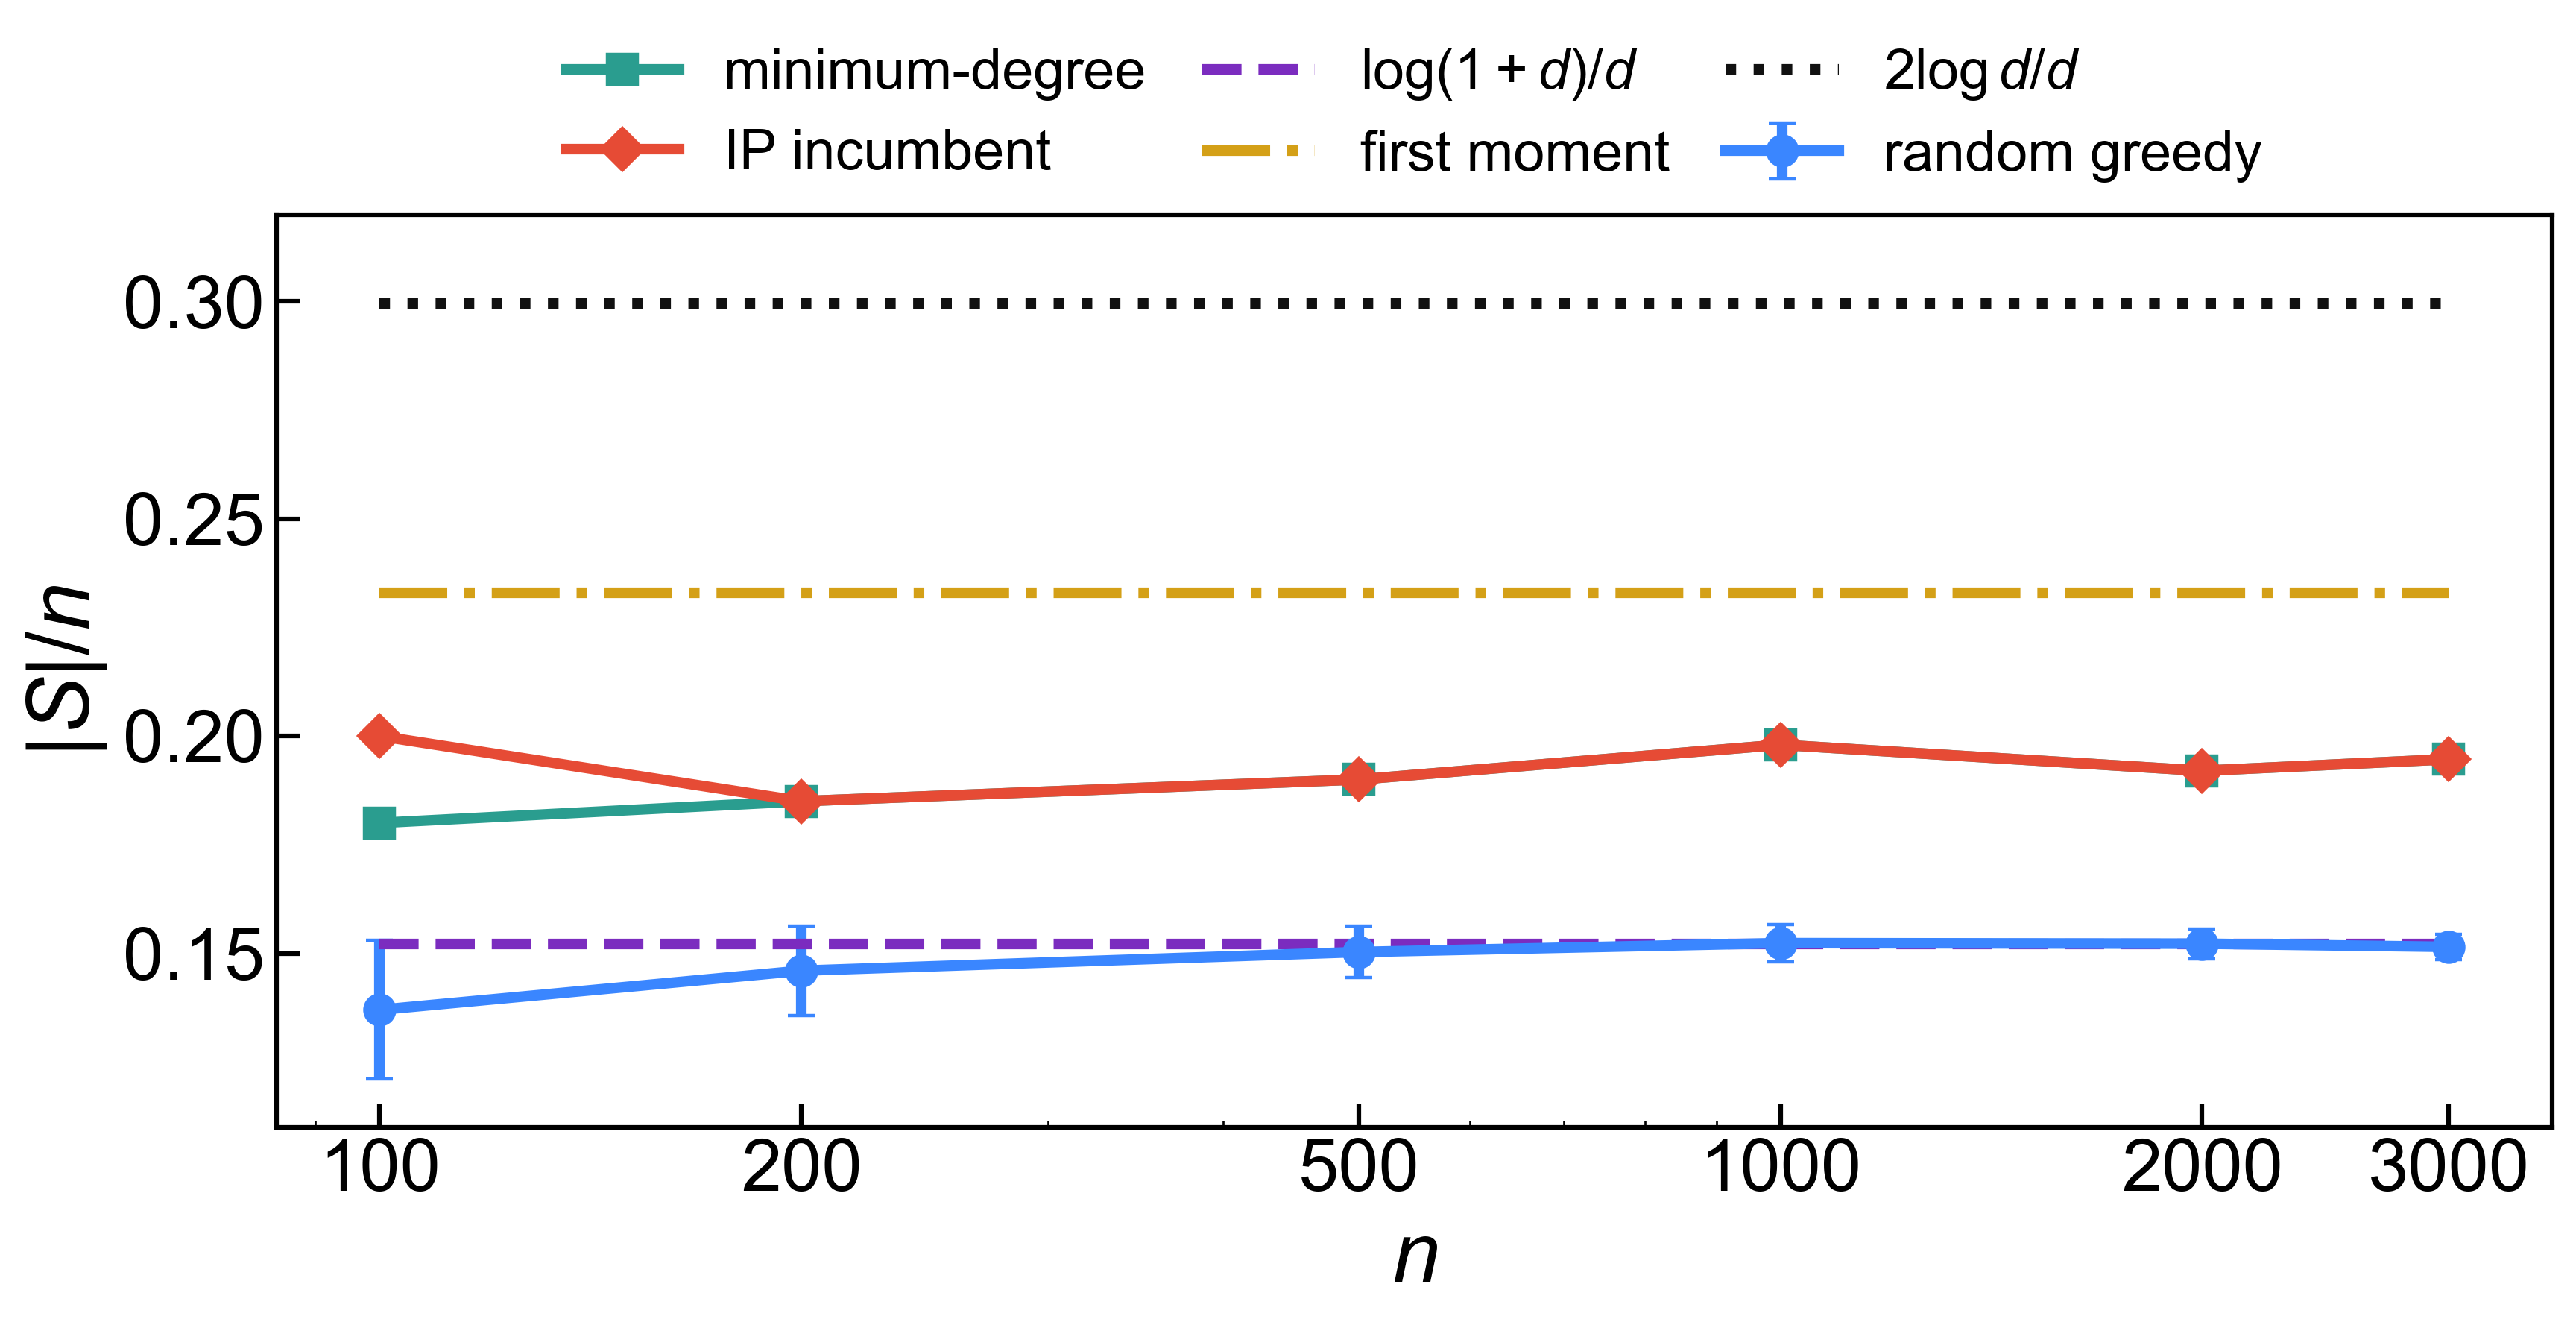

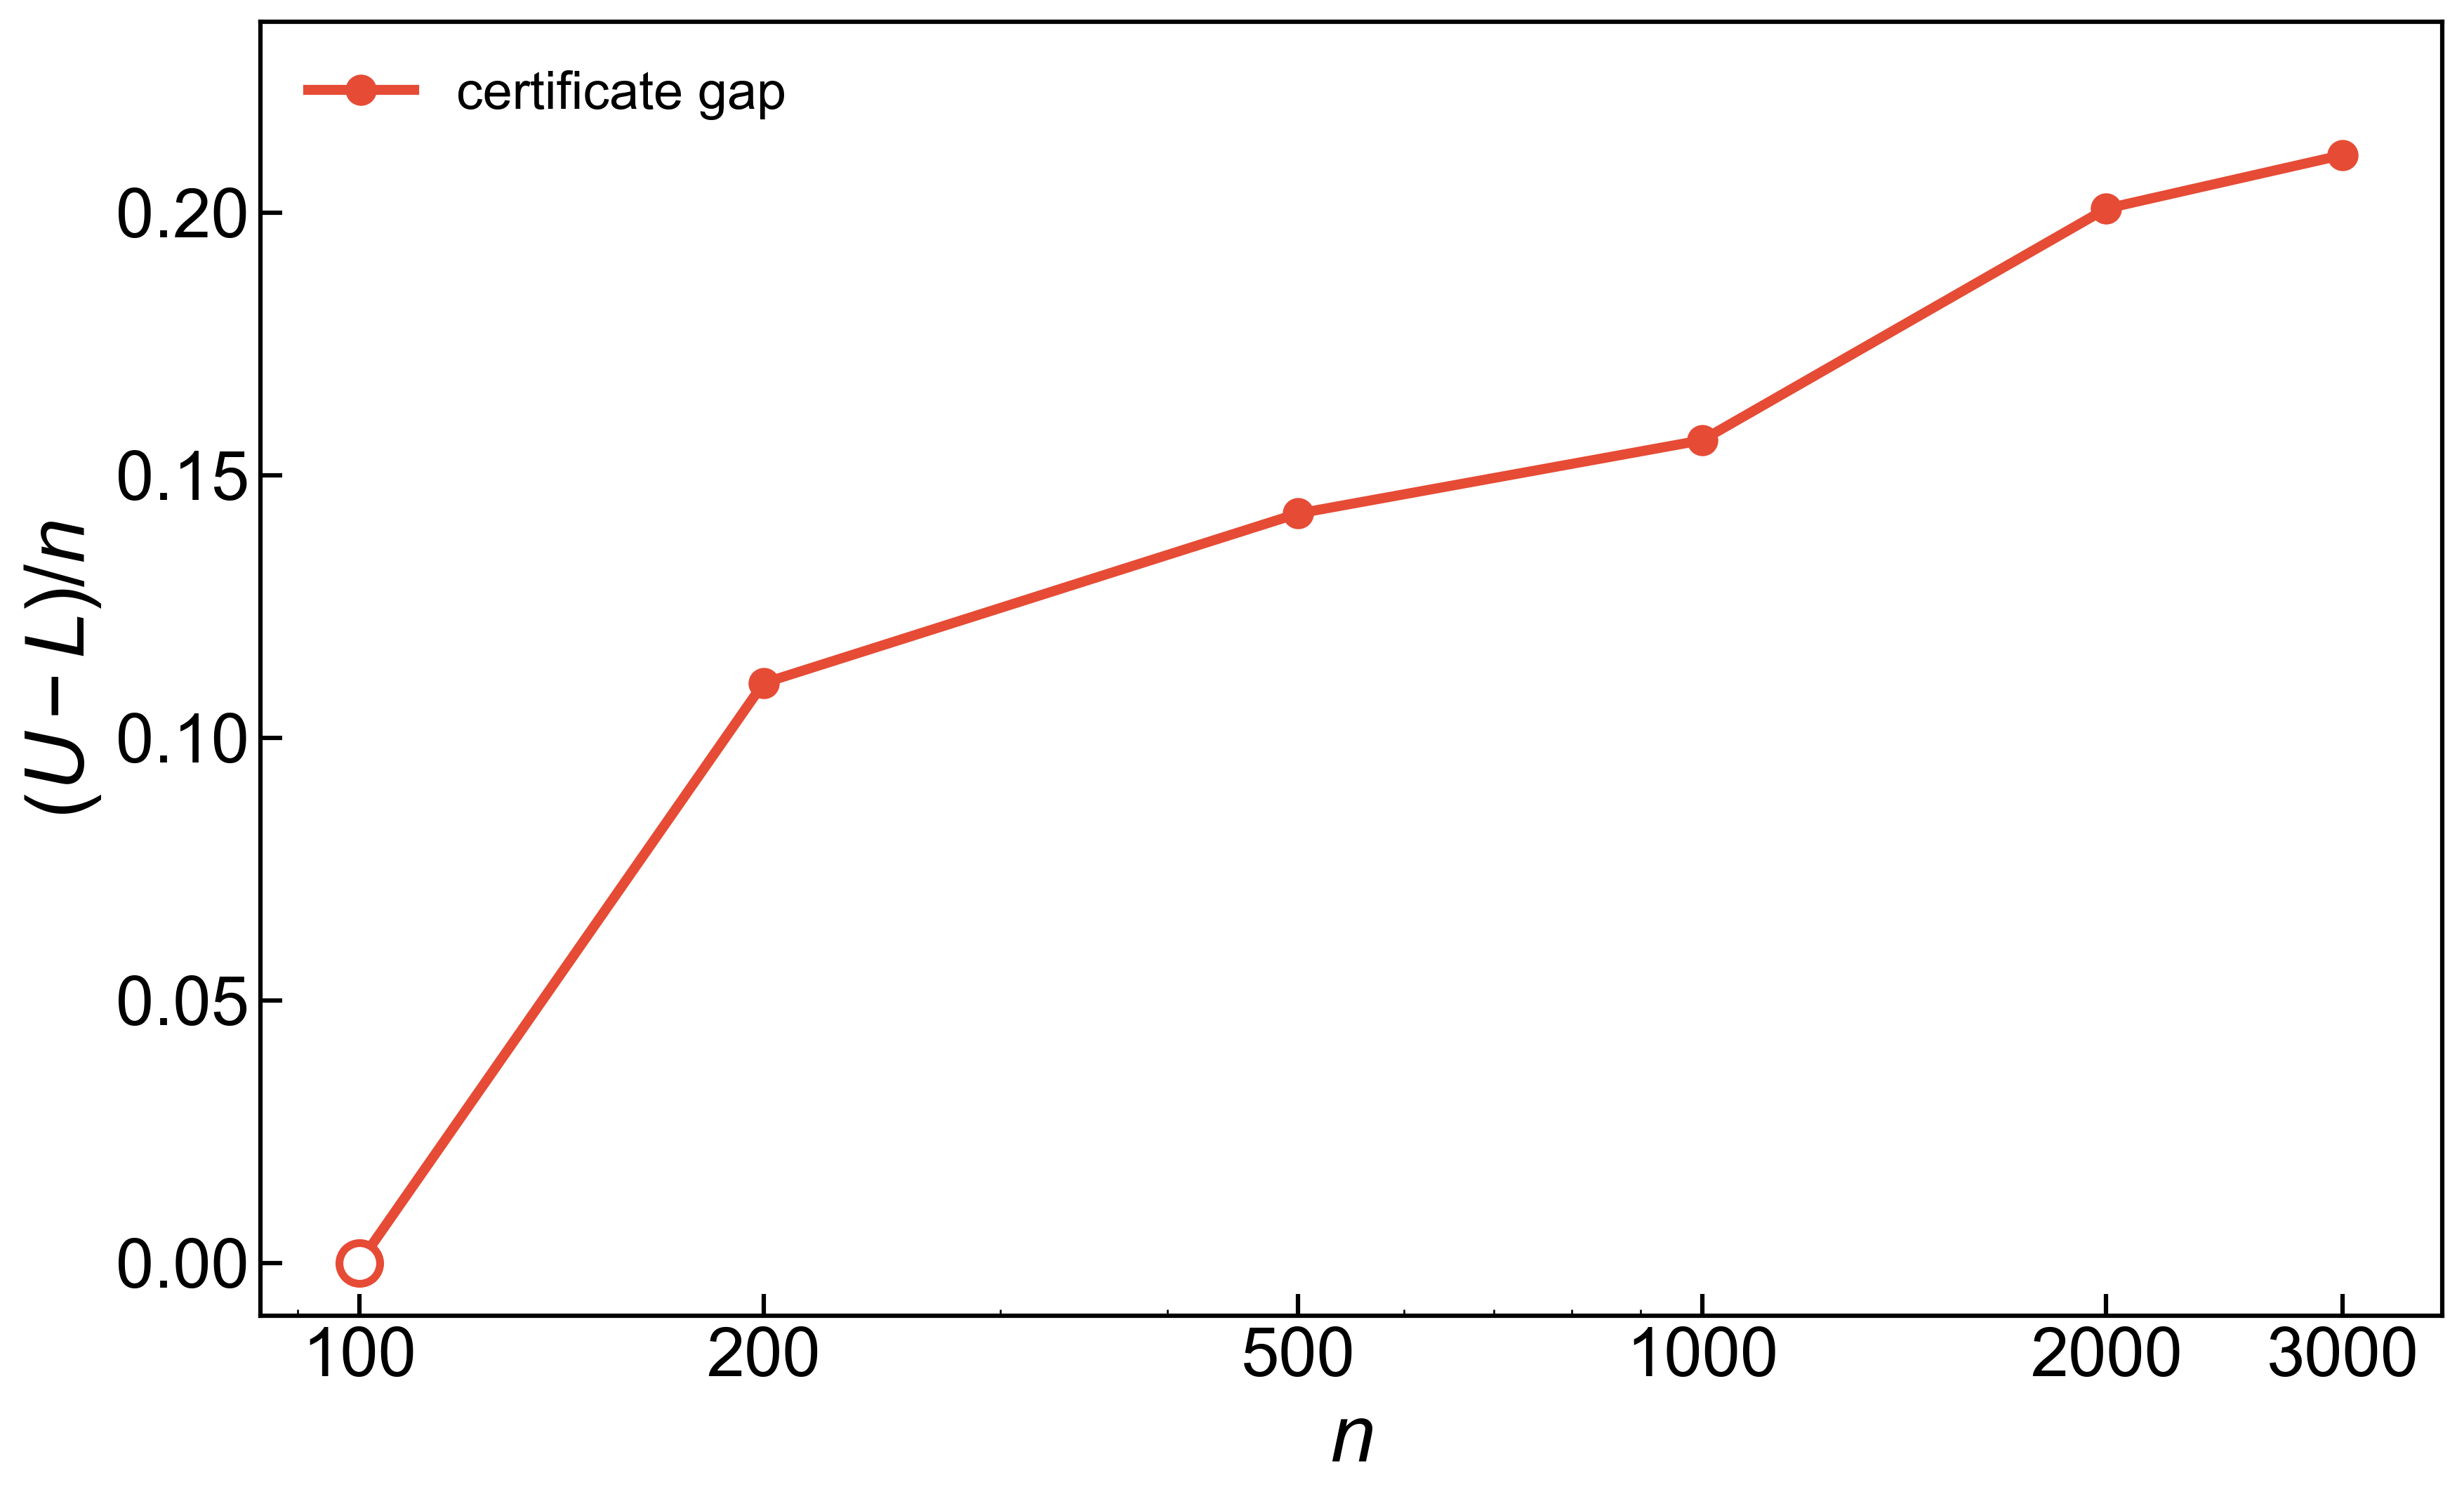

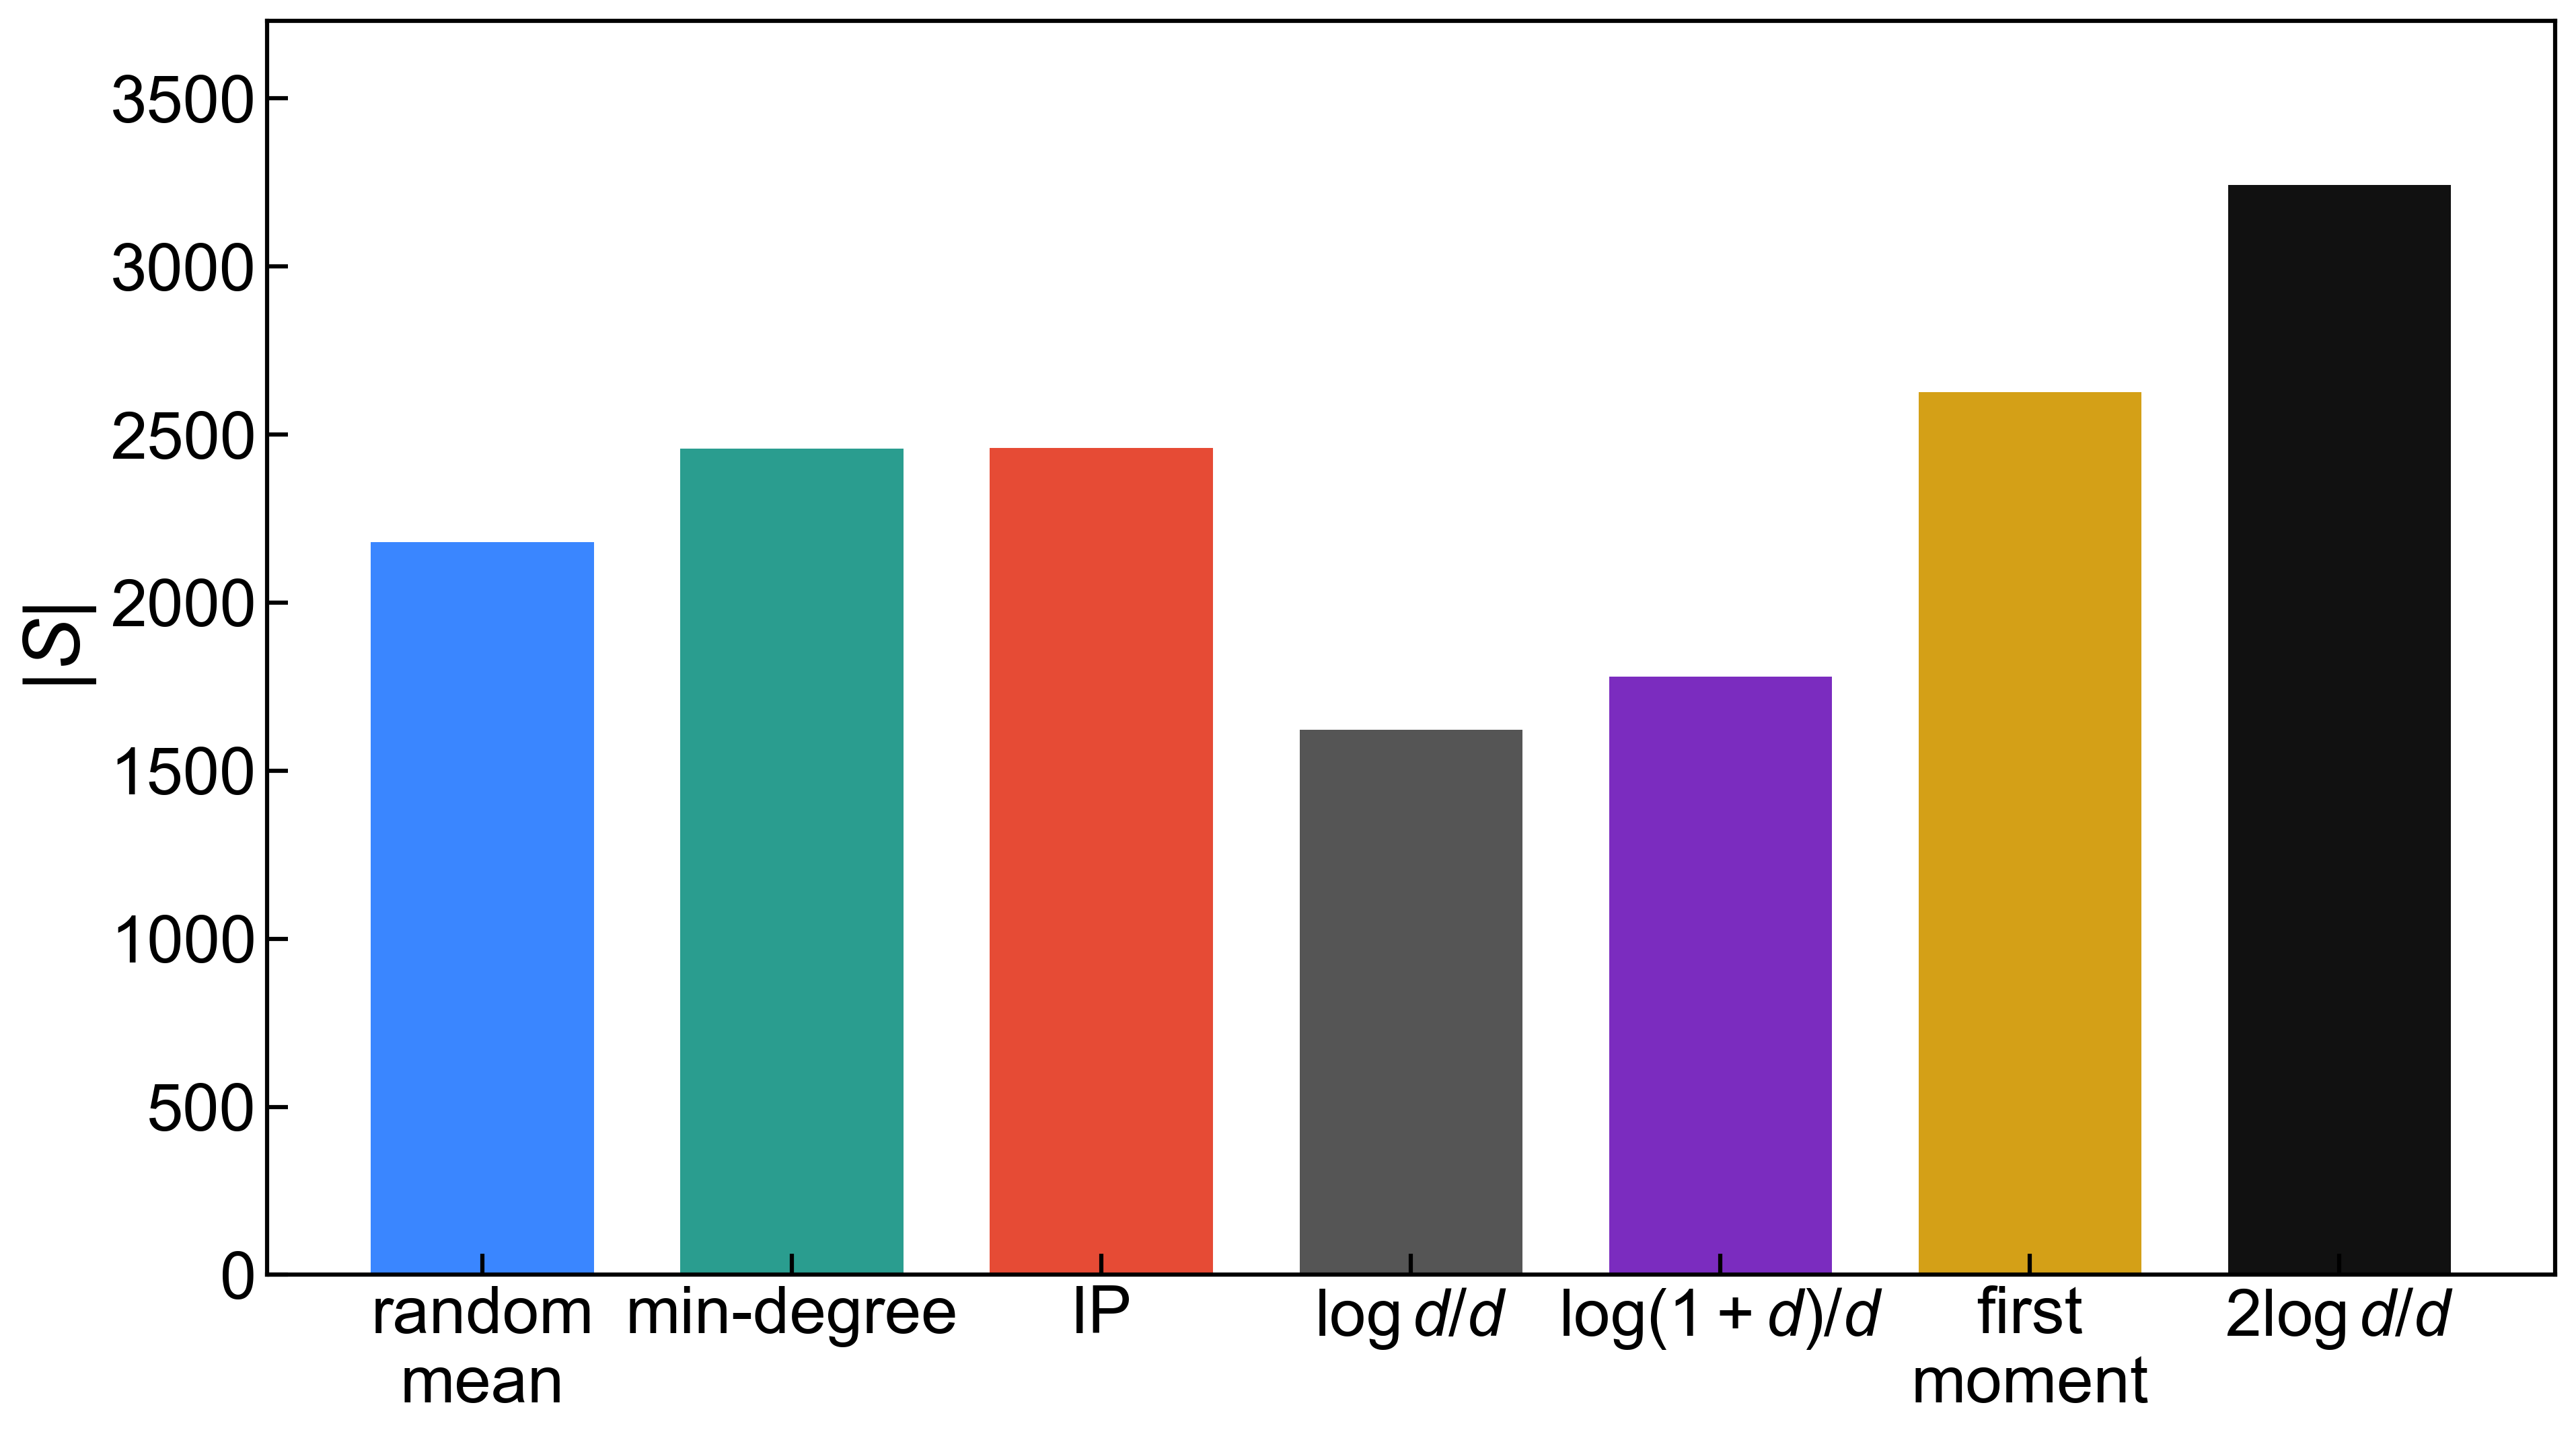

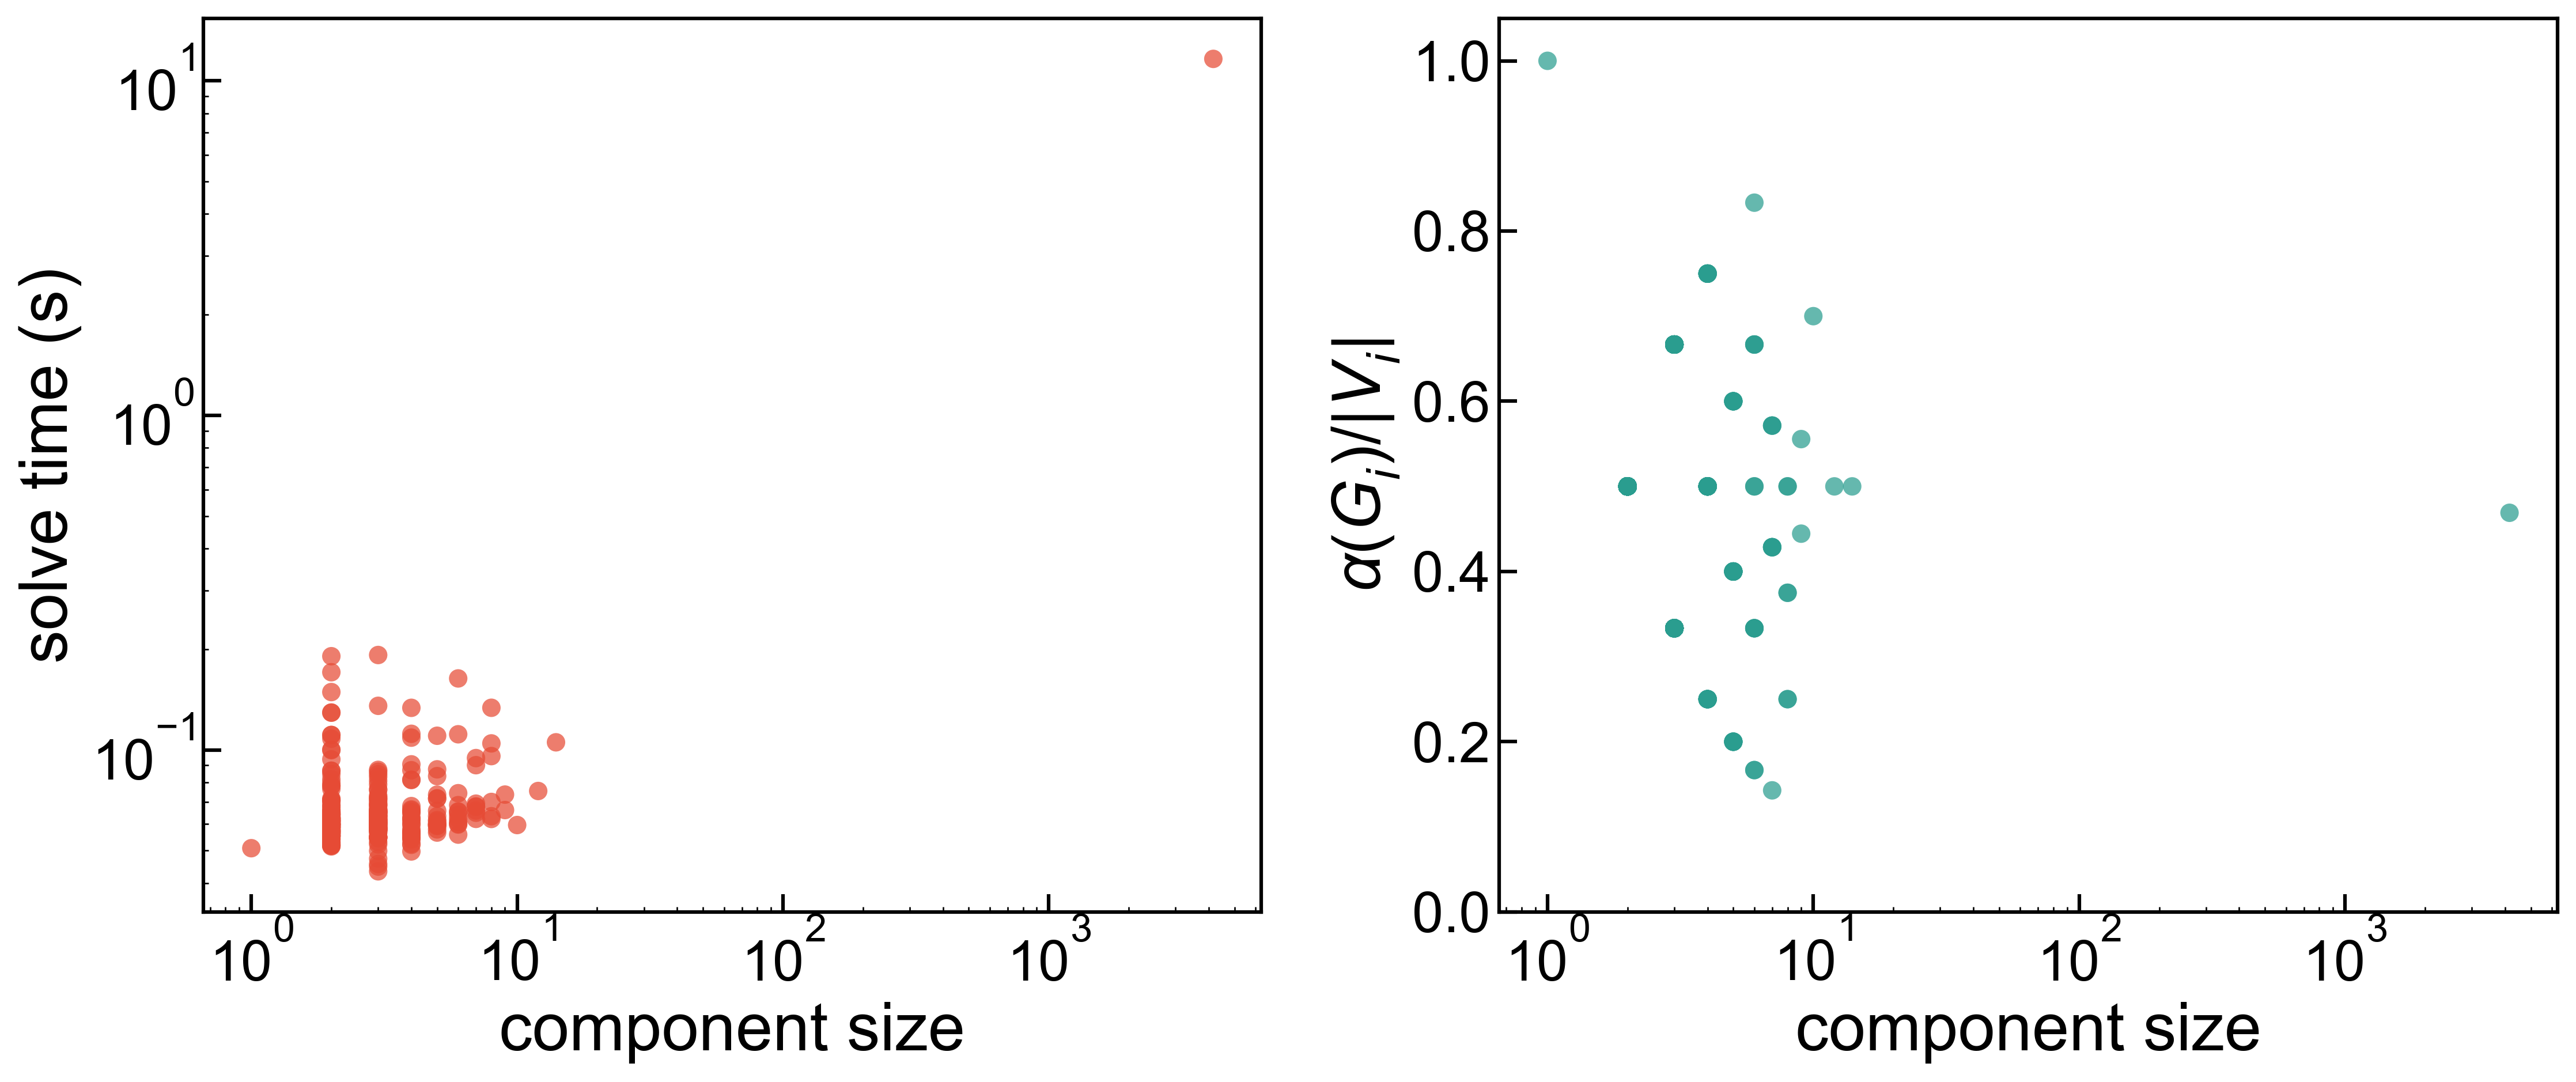

In [12]:
if REBUILD_FIGURES:
    make_plots(er, snap, component_results)

for figure in [
    "figure1_er_ratios.png",
    "figure2_er_certificate_gap.png",
    "figure3_snap_comparison.png",
    "figure4_snap_component_profile.png",
]:
    display(Image(filename=str(RESULTS_DIR / figure)))

## Long-Batch Results

The cached multi-seed random-graph experiment is the main random-graph evidence. The single-seed low-time-limit comparison above is kept as a compact check; the table and figures below aggregate the configured multi-seed profile from `results/long_batch/er_long_results.csv`.

Recorded long-batch rows: 115
Clean solver rows: 115
Solver-execution errors: 0


,rows
ip_status,
TimeLimit,95
Optimal,20


,n,attempted,runs,errors,optimal,no_certificate,random_ratio_mean,random_ratio_sd,min_degree_ratio_mean,incumbent_ratio_mean,upper_bound_ratio_mean,gap_ratio_mean,runtime_sec_mean,log1p_ratio,first_moment_ratio
0,100,20,20,0,20,0,0.1442,0.0028,0.1830,0.1990,0.1990,0.0000,14.3,0.1522,0.233
1,200,20,20,0,0,20,0.1485,0.0036,0.1888,0.1962,0.2513,0.0550,300.6,0.1522,0.233
2,500,20,20,0,0,20,0.1508,0.0018,0.1924,0.1924,0.3219,0.1295,290.7,0.1522,0.233
3,1000,20,20,0,0,20,0.1515,0.0009,0.1931,0.1931,0.3552,0.1621,161.2,0.1522,0.233
4,1500,10,10,0,0,10,0.1515,0.0008,0.1955,0.1955,0.3678,0.1723,599.6,0.1522,0.233
5,2000,10,10,0,0,10,0.1519,0.0009,0.1965,0.1965,0.3760,0.1796,596.9,0.1522,0.233
6,3000,10,10,0,0,10,0.1521,0.0009,0.1953,0.1953,0.4000,0.2047,403.5,0.1522,0.233
7,5000,5,5,0,0,5,0.1522,0.0007,0.1958,0.1958,0.4293,0.2335,596.3,0.1522,0.233


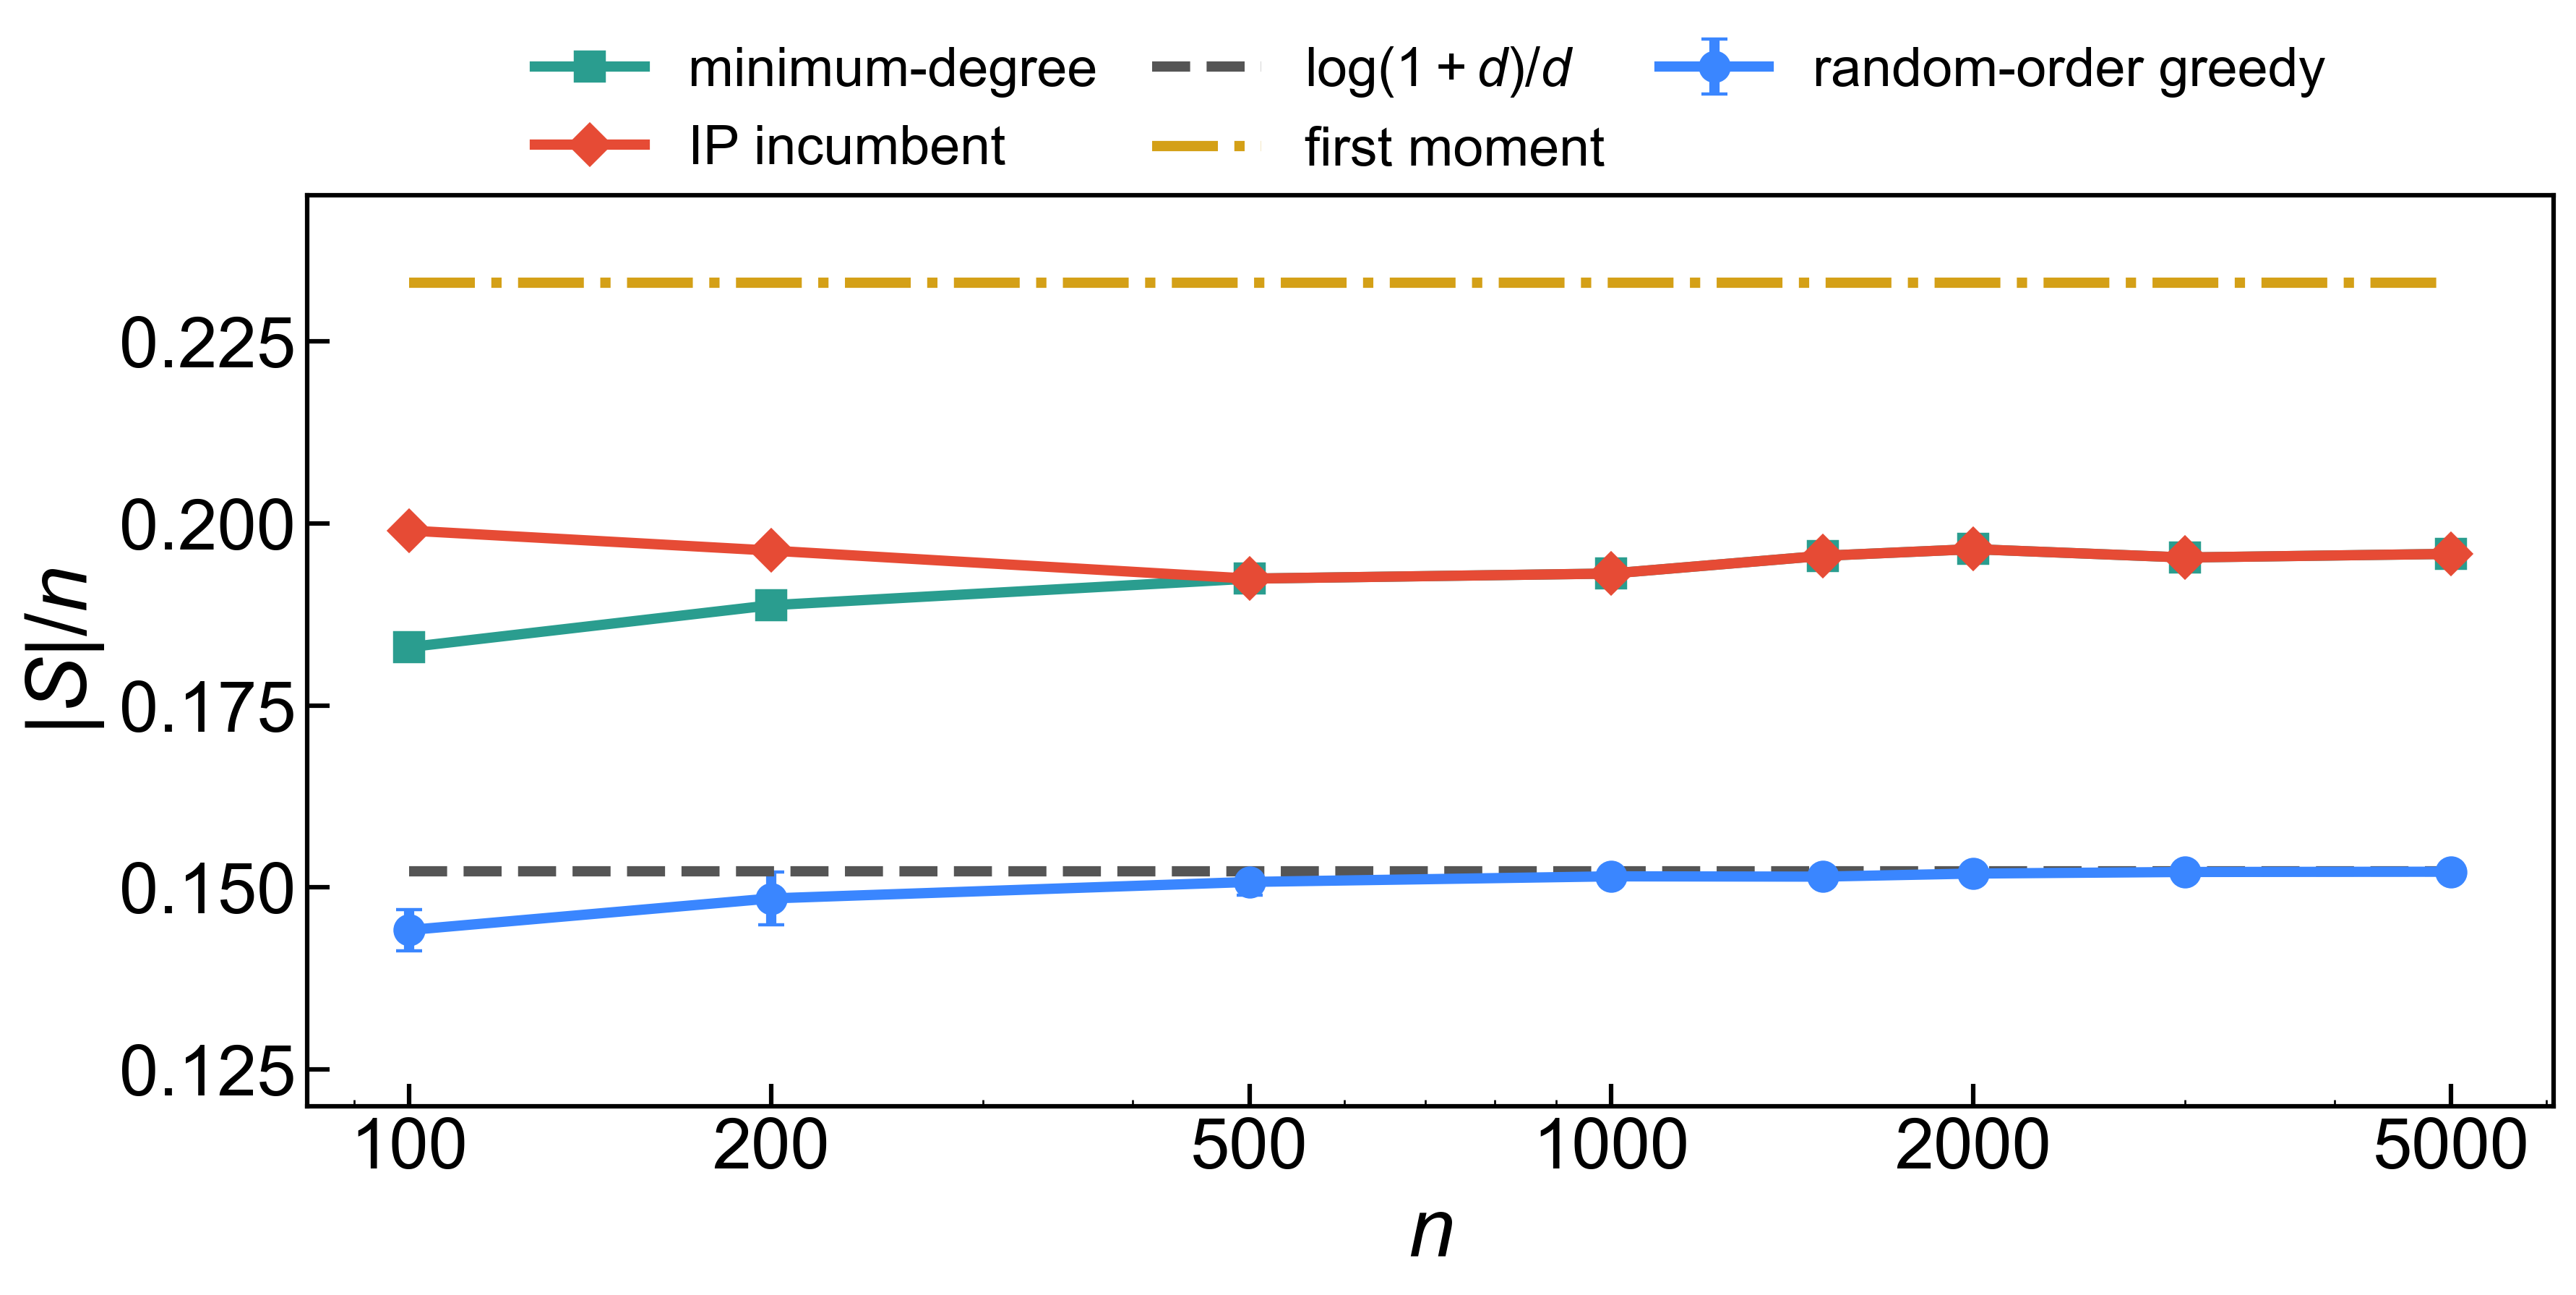

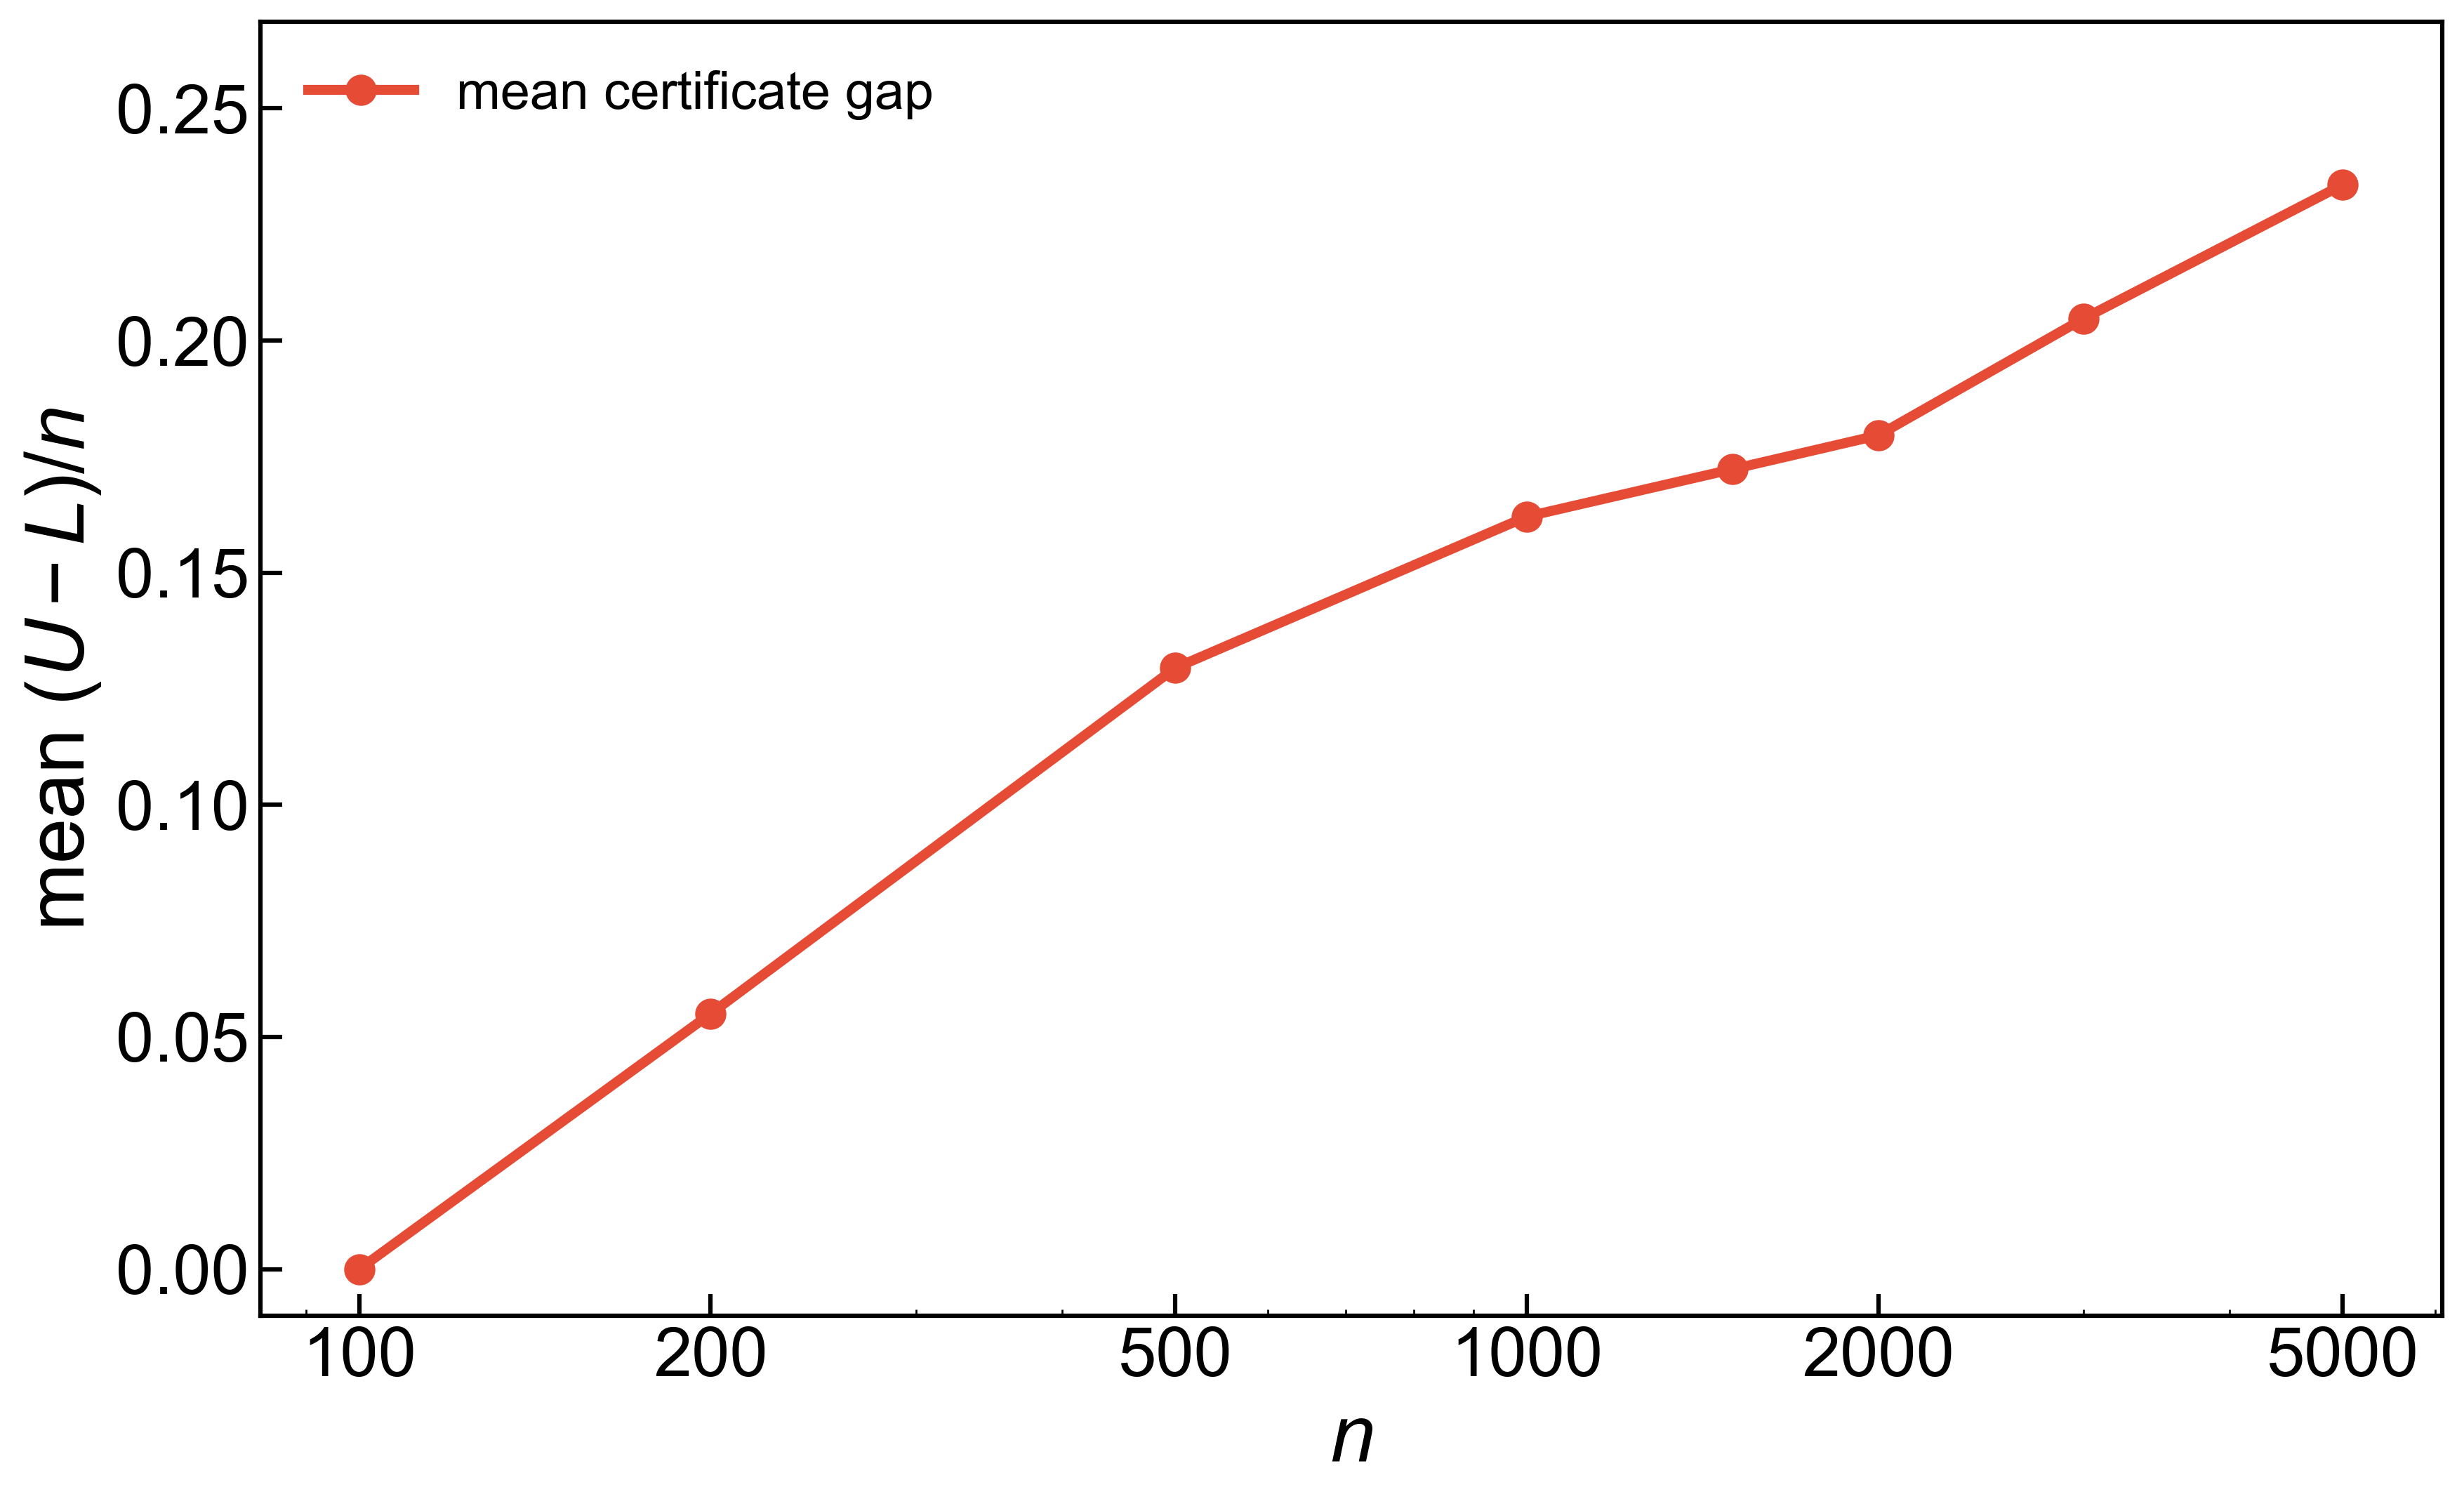

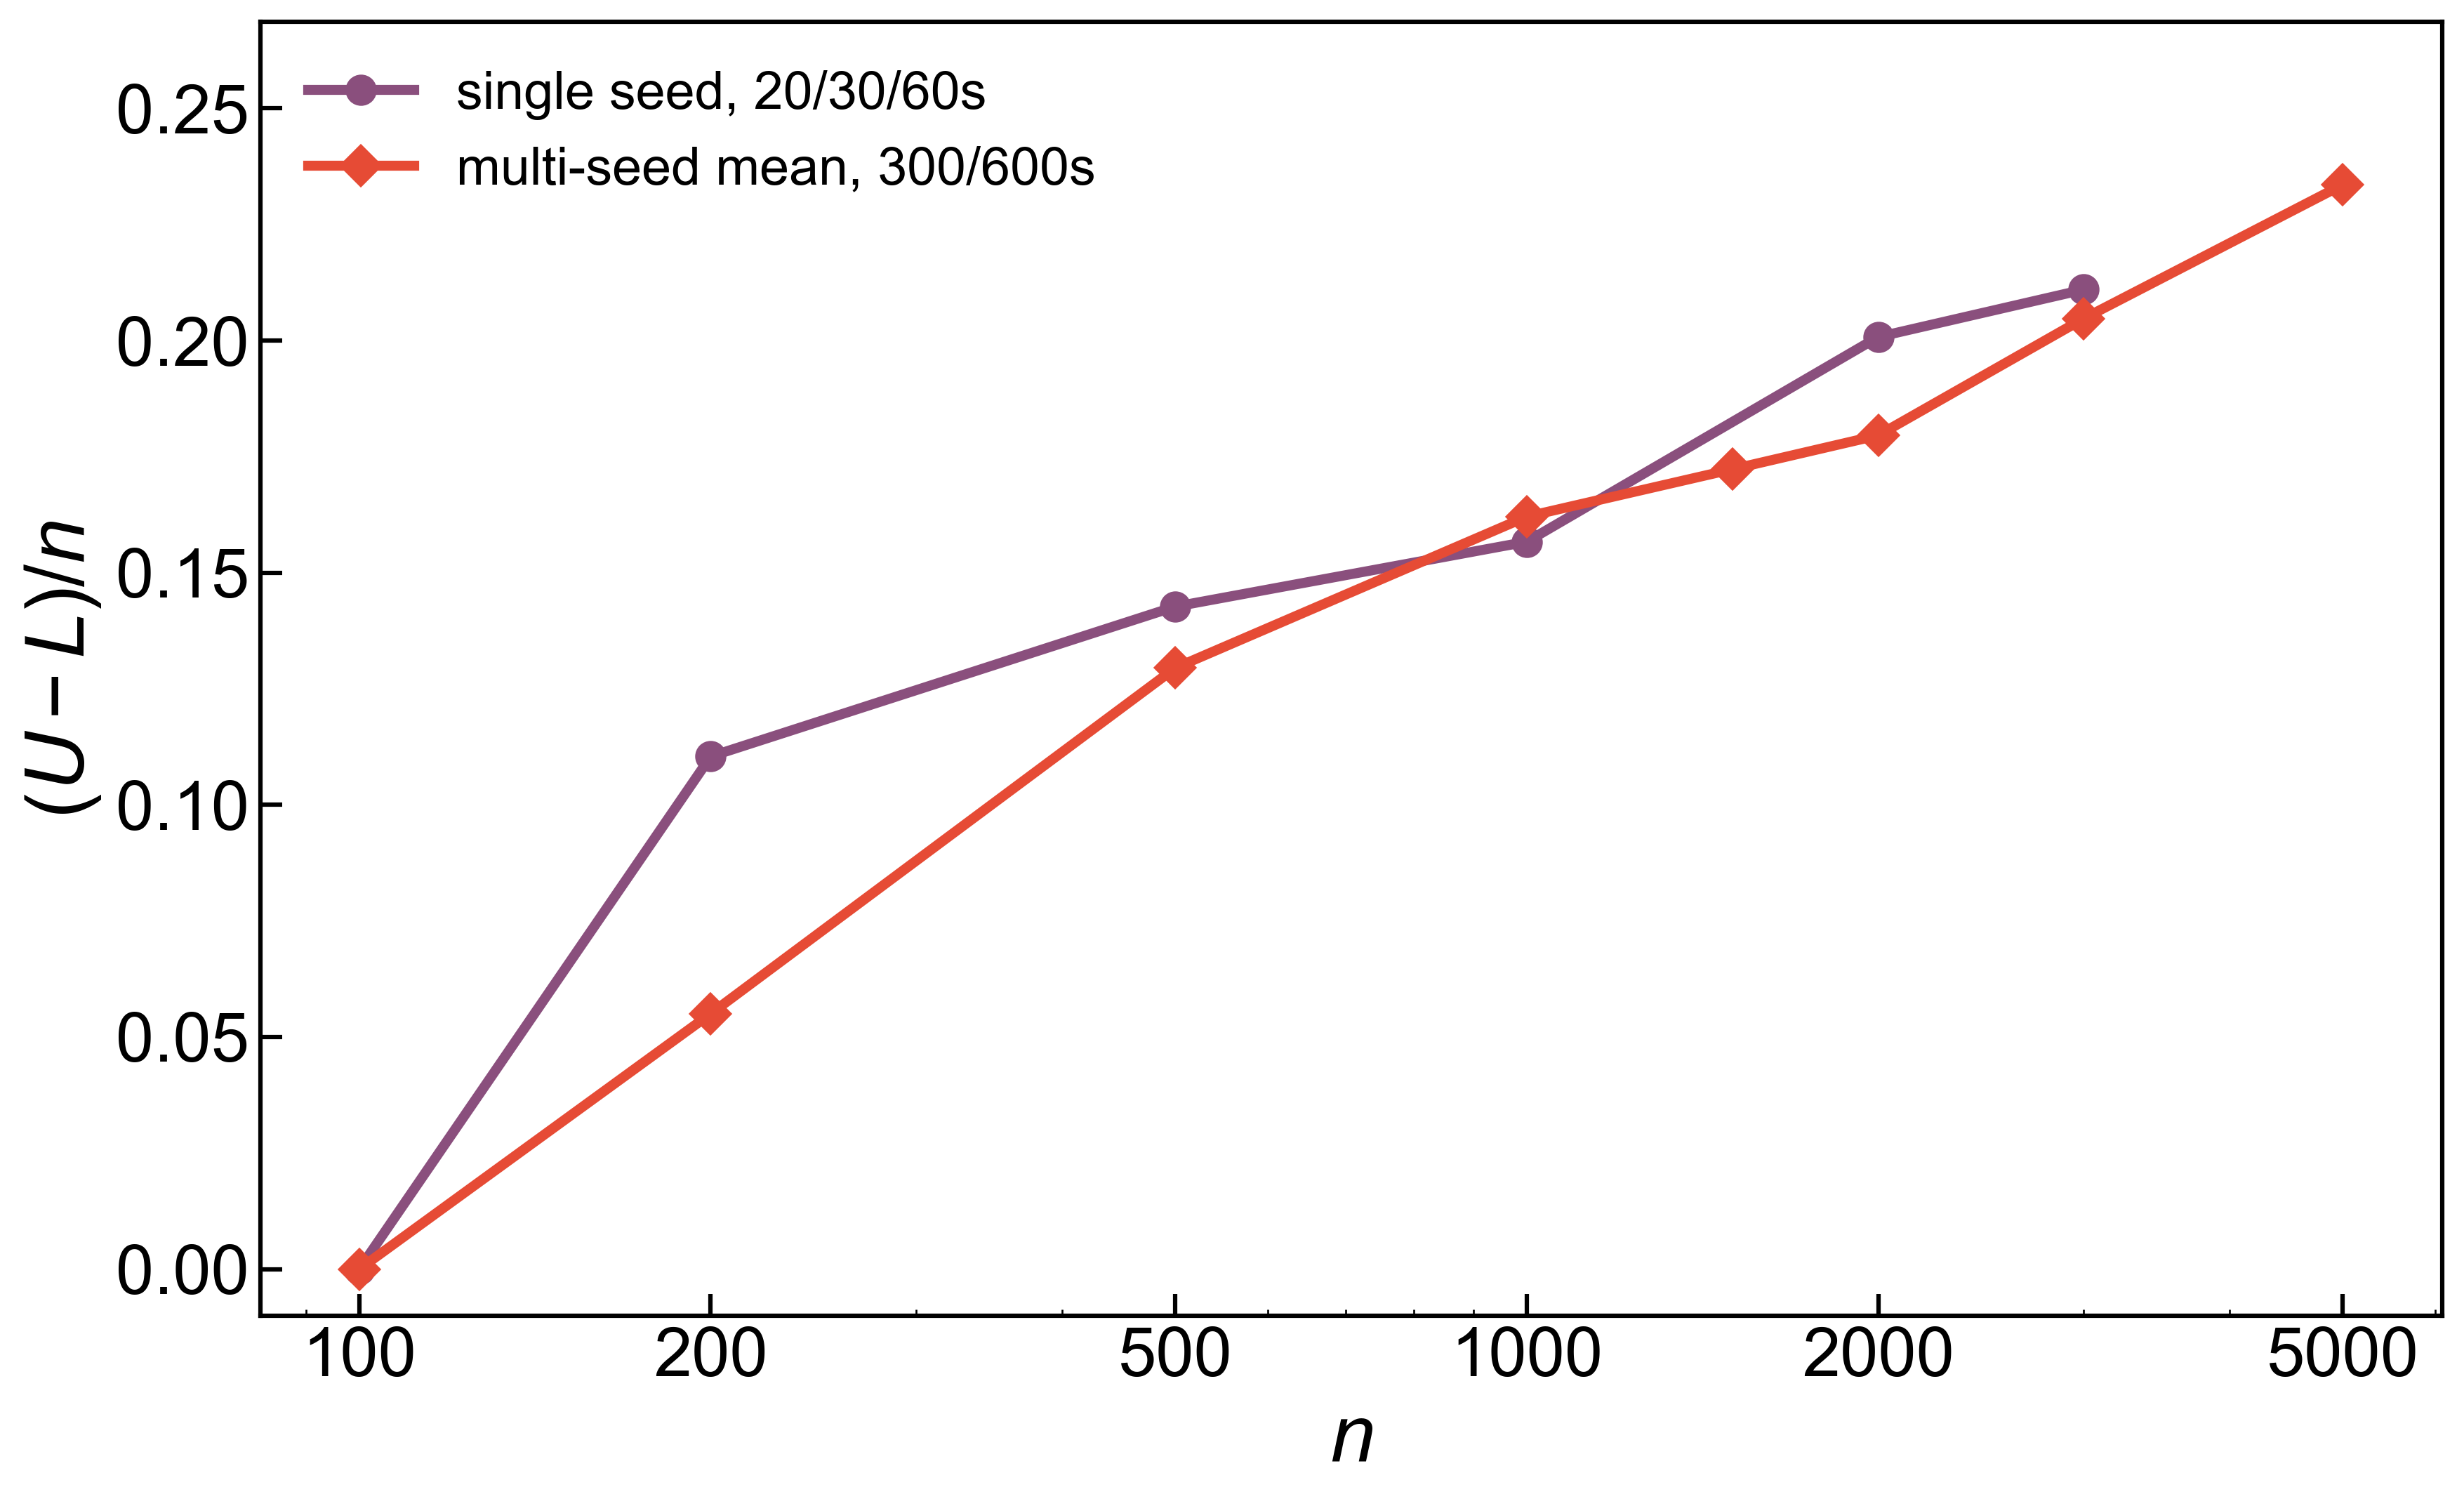


Last log lines:
[110/115] phase=B_scaling n=3000 d=20.0 seed=9 limit=600.0s
    status=TimeLimit incumbent=577 ub=1218.0 runtime=590.2462631250019 error=
[111/115] phase=B_scaling n=5000 d=20.0 seed=0 limit=600.0s
    status=TimeLimit incumbent=969 ub=2148.0 runtime=588.6838364159994 error=
[112/115] phase=B_scaling n=5000 d=20.0 seed=1 limit=600.0s
    status=TimeLimit incumbent=986 ub=2144.609 runtime=578.3789334159992 error=
[113/115] phase=B_scaling n=5000 d=20.0 seed=2 limit=600.0s
    status=TimeLimit incumbent=979 ub=2144.5 runtime=644.859234042 error=
[114/115] phase=B_scaling n=5000 d=20.0 seed=3 limit=600.0s
    status=TimeLimit incumbent=973 ub=2148.5 runtime=585.5042148339962 error=
[115/115] phase=B_scaling n=5000 d=20.0 seed=4 limit=600.0s
    status=TimeLimit incumbent=988 ub=2148.0 runtime=583.878095125001 error=



In [13]:
long_csv = LONG_BATCH_DIR / "er_long_results.csv"
long_log = LONG_BATCH_DIR / "main.log"
long_summary_path = LONG_BATCH_DIR / "long_batch_summary.csv"

if long_csv.exists():
    long_df = pd.read_csv(long_csv)
    error_text = long_df["error"].fillna("").astype(str).str.strip()
    long_usable = long_df[error_text.eq("")].copy()
    long_errors = long_df[error_text.ne("")].copy()

    print(f"Recorded long-batch rows: {len(long_df)}")
    print(f"Clean solver rows: {len(long_usable)}")
    print(f"Solver-execution errors: {len(long_errors)}")
    display(long_df["ip_status"].fillna("ERROR").value_counts().rename("rows").to_frame())

    if not long_errors.empty:
        display(long_errors[["phase", "n", "seed", "time_limit", "error"]])

    long_usable["random_ratio"] = long_usable["greedy_random_mean"] / long_usable["n"]
    long_usable["random_best_ratio"] = long_usable["greedy_random_best"] / long_usable["n"]
    long_usable["min_degree_ratio"] = long_usable["greedy_min_degree"] / long_usable["n"]
    long_usable["incumbent_ratio"] = long_usable["ip_incumbent"] / long_usable["n"]
    long_usable["upper_bound_ratio"] = long_usable["ip_upper_bound"] / long_usable["n"]
    long_usable["gap_ratio"] = (long_usable["ip_upper_bound"] - long_usable["ip_incumbent"]).clip(lower=0) / long_usable["n"]
    long_usable["log1p_ratio"] = long_usable["threshold_log1pd"] / long_usable["n"]
    long_usable["first_moment_ratio"] = long_usable["first_moment_threshold"] / long_usable["n"]

    long_summary = long_usable.groupby("n").agg(
        runs=("n", "size"),
        optimal=("ip_status", lambda s: int((s == "Optimal").sum())),
        no_certificate=("ip_status", lambda s: int((s != "Optimal").sum())),
        random_ratio_mean=("random_ratio", "mean"),
        random_ratio_sd=("random_ratio", "std"),
        min_degree_ratio_mean=("min_degree_ratio", "mean"),
        incumbent_ratio_mean=("incumbent_ratio", "mean"),
        upper_bound_ratio_mean=("upper_bound_ratio", "mean"),
        gap_ratio_mean=("gap_ratio", "mean"),
        runtime_sec_mean=("ip_runtime_sec", "mean"),
        log1p_ratio=("log1p_ratio", "mean"),
        first_moment_ratio=("first_moment_ratio", "mean"),
    ).reset_index()

    attempted_by_n = long_df.groupby("n").size().rename("attempted").reset_index()
    error_by_n = long_errors.groupby("n").size().rename("errors").reset_index()
    long_summary = long_summary.merge(attempted_by_n, on="n", how="left").merge(error_by_n, on="n", how="left")
    long_summary["errors"] = long_summary["errors"].fillna(0).astype(int)
    front = ["n", "attempted", "runs", "errors", "optimal", "no_certificate"]
    long_summary = long_summary[front + [c for c in long_summary.columns if c not in front]]
    long_summary.to_csv(long_summary_path, index=False)

    display(long_summary.round({
        "random_ratio_mean": 4,
        "random_ratio_sd": 4,
        "min_degree_ratio_mean": 4,
        "incumbent_ratio_mean": 4,
        "upper_bound_ratio_mean": 4,
        "gap_ratio_mean": 4,
        "runtime_sec_mean": 1,
        "log1p_ratio": 4,
        "first_moment_ratio": 4,
    }))

    if REBUILD_FIGURES and not long_summary.empty:
        set_plot_style()
        colors = {
            "random": "#3A86FF",
            "mindeg": "#2A9D8F",
            "ip": "#E64B35",
            "ub": "#8A4F7D",
            "log1p": "#555555",
            "fm": "#D4A017",
        }
        x = long_summary["n"].to_numpy()
        tick_values = [100, 200, 500, 1000, 2000, 5000]
        final_report_dirs = [FINAL_REPORT_RESULTS_DIR] if FINAL_REPORT_RESULTS_DIR.exists() else []

        fig, ax = plt.subplots(figsize=(11.5, 7.2))
        ax.errorbar(x, long_summary["random_ratio_mean"], yerr=long_summary["random_ratio_sd"].fillna(0), marker="o", capsize=4, color=colors["random"], label="random-order greedy")
        ax.plot(x, long_summary["min_degree_ratio_mean"], marker="s", color=colors["mindeg"], label="minimum-degree")
        ax.plot(x, long_summary["incumbent_ratio_mean"], marker="D", color=colors["ip"], label="IP incumbent")
        ax.plot(x, long_summary["log1p_ratio"], linestyle="--", color=colors["log1p"], label=r"$\log(1+d)/d$")
        ax.plot(x, long_summary["first_moment_ratio"], linestyle="-.", color=colors["fm"], label="first moment")
        ax.set_xlabel(r"$n$")
        ax.set_ylabel(r"$|S|/n$")
        ax.set_xscale("log")
        ax.set_xticks(tick_values)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_ylim(0.12, 0.245)
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=3, frameon=False, handlelength=2.0, columnspacing=1.0)
        fig.tight_layout(rect=(0, 0, 1, 0.90))
        save_figure(fig, "figure5_long_batch_ratios", extra_dirs=final_report_dirs)
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(11.5, 7.2))
        ax.plot(x, long_summary["gap_ratio_mean"], marker="o", color=colors["ip"], label="mean certificate gap")
        ax.plot(x, long_summary["upper_bound_ratio_mean"] - long_summary["incumbent_ratio_mean"], alpha=0)
        ax.set_xlabel(r"$n$")
        ax.set_ylabel(r"mean $(U-L)/n$")
        ax.set_xscale("log")
        ax.set_xticks(tick_values)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_ylim(-0.01, max(0.25, float(long_summary["gap_ratio_mean"].max()) * 1.15))
        ax.legend(loc="upper left")
        fig.tight_layout()
        save_figure(fig, "figure6_long_batch_gap", extra_dirs=final_report_dirs)
        plt.close(fig)

        if "er" in globals() and not er.empty:
            short = er[er["n"].isin(long_summary["n"])].copy()
            short["gap_ratio"] = (short["ip_mis_upper_bound"] - short["ip_feasible"]).clip(lower=0) / short["n"]
            fig, ax = plt.subplots(figsize=(11.5, 7.2))
            ax.plot(short["n"], short["gap_ratio"], marker="o", color=colors["ub"], label="single seed, 20/30/60s")
            ax.plot(x, long_summary["gap_ratio_mean"], marker="D", color=colors["ip"], label="multi-seed mean, 300/600s")
            ax.set_xlabel(r"$n$")
            ax.set_ylabel(r"$(U-L)/n$")
            ax.set_xscale("log")
            ax.set_xticks(tick_values)
            ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
            ymax = max(float(short["gap_ratio"].max()), float(long_summary["gap_ratio_mean"].max()))
            ax.set_ylim(-0.01, max(0.25, ymax * 1.15))
            ax.legend(loc="upper left")
            fig.tight_layout()
            save_figure(fig, "figure7_time_limit_gap_comparison", extra_dirs=final_report_dirs)
            plt.close(fig)

        display(Image(filename=str(RESULTS_DIR / "figure5_long_batch_ratios.png")))
        display(Image(filename=str(RESULTS_DIR / "figure6_long_batch_gap.png")))
        display(Image(filename=str(RESULTS_DIR / "figure7_time_limit_gap_comparison.png")))
else:
    print("No long-batch CSV yet.")

if long_log.exists():
    print("\nLast log lines:")
    print("".join(long_log.read_text(errors="replace").splitlines(True)[-12:]))

if RUN_LONG_BATCH_IN_NOTEBOOK:
    run_long_batch_from_notebook(profile="main", random_trials=100)

## Interpretation

The long-batch random-graph runs tell a consistent story. Random-order greedy stays close to the finite-$d$ prediction $\log(1+d)/d$, while the minimum-degree warm start is already much larger. CBC then has little room to improve the incumbent on most large instances; the hard part is proving a matching upper bound during the configured solve. Thus the project outcome is not that the solver fails to find large independent sets, but that certification becomes the expensive step.

For SNAP ca-GrQc, component decomposition changes the computational picture. The notebook records $\alpha(G)=2459$, with minimum-degree greedy only one vertex below optimum. The matched Erdős-Rényi control is included as a null-model comparison rather than a prediction of real-network behavior.